<a href="https://colab.research.google.com/github/microsoft/qlib/blob/main/examples/workflow_by_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install fredapi

=== 🌍 1단계: FRED 매크로 데이터 다운로드 및 국면 판별 ===
 -> 매크로 판별 완료!

=== 📈 2단계: 야후 파이낸스(yfinance) ETF 데이터 로드 ===
 -> 야후 파이낸스 다운로드 완료 (테스트 기간: 2006-03-20 ~ )

=== ⚙️ 3단계: 매크로 기반 섹터 로테이션 백테스트 실행 ===
=== 📊 최종 성과 요약 (Dual Benchmark) ===
테스트 기간: 2006-03-20 ~ 2026-03-20 (20.0년)
----------------------------------------
🏆 매크로 로테이션:  CAGR:  10.70% | MDD: -31.15% | Sharpe: 0.70
🇺🇸 벤치마크 (SPY):   CAGR:  10.38% | MDD: -55.19%
⚖️ 벤치마크 (RSP):   CAGR:   9.30% | MDD: -59.92%
----------------------------------------


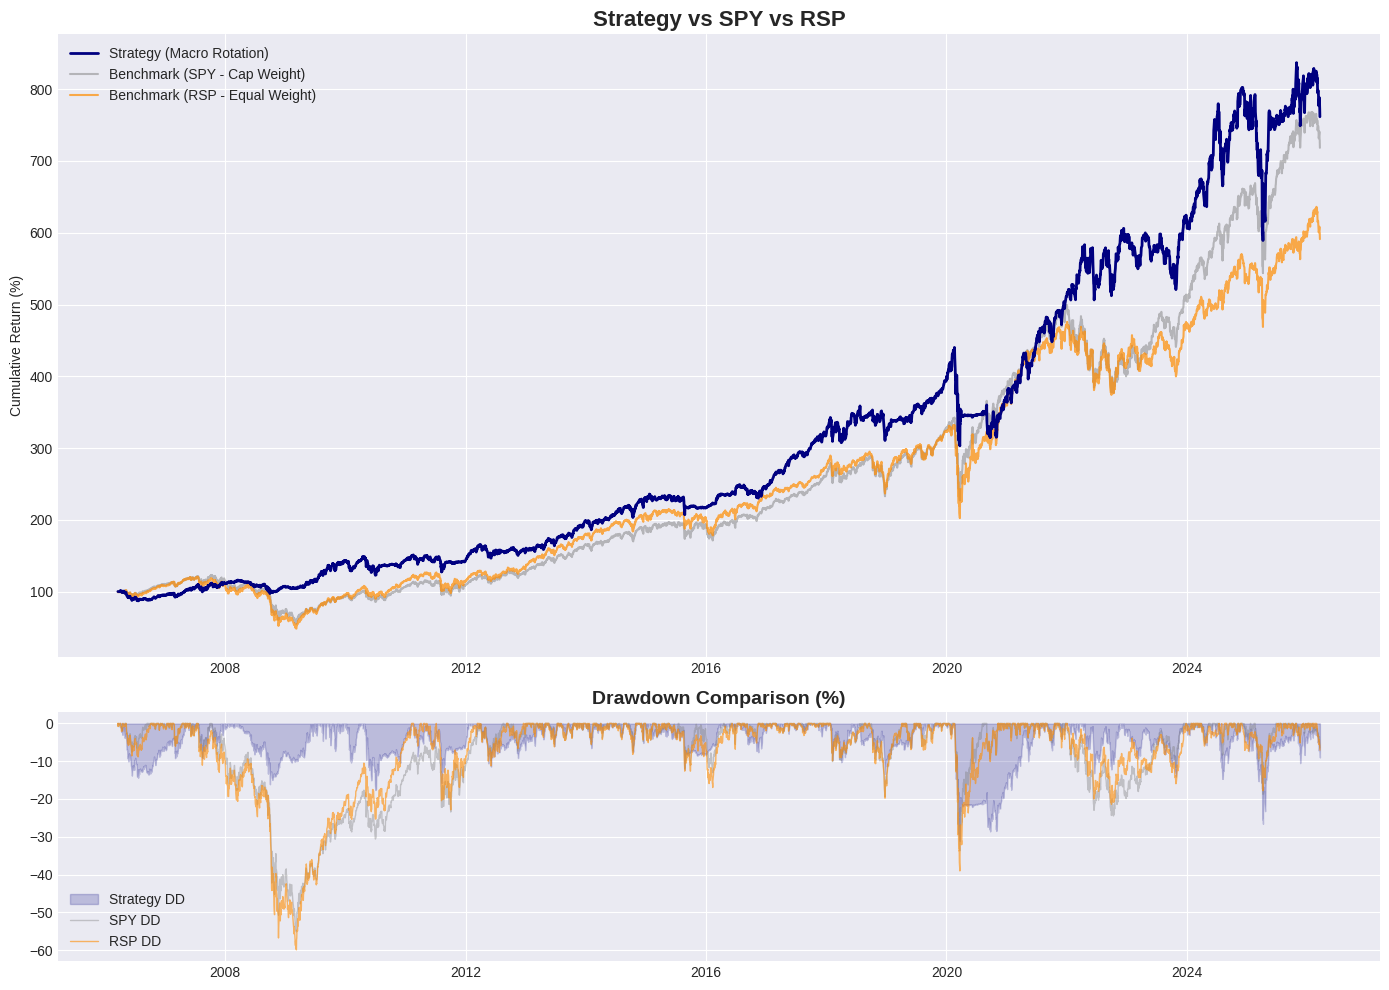

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5' # ★ 반드시 본인의 키로 변경!
fred = Fred(api_key=FRED_API_KEY)

print("=== 🌍 1단계: FRED 매크로 데이터 다운로드 및 국면 판별 ===")
try:
    s_growth = fred.get_series('INDPRO')
    s_inflation = fred.get_series('CPIAUCSL')
    s_cli = fred.get_series('USALOLITOAASTSAM')
    s_hy = fred.get_series('BAMLH0A0HYM2')

    df_macro = pd.concat([s_growth, s_inflation, s_cli, s_hy], axis=1)
    df_macro.columns = ['Growth', 'Inflation', 'CLI', 'HY_Spread']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12) * 100).rolling(3).mean().diff(1)
    df_macro['Inflation_Mom'] = (df_macro['Inflation'].pct_change(12) * 100).rolling(3).mean().diff(1)
    df_macro['CLI_Mom'] = df_macro['CLI'].rolling(3).mean().diff(1)
    df_macro['HY_Change'] = df_macro['HY_Spread'].diff(3)

    def get_regime(row):
        g, i, c, hy, hy_c = row['Growth_Mom'], row['Inflation_Mom'], row['CLI_Mom'], row['HY_Spread'], row['HY_Change']
        if pd.isna(g) or pd.isna(i) or pd.isna(c) or pd.isna(hy): return 'None'

        if hy > 5.0 and hy_c > 0.5: return 'Risk_Off'

        adj_g = c if (c > 0 and g < 0) or (c < 0 and g > 0) else g

        if adj_g >= 0 and i < 0: return 'Early'
        elif adj_g >= 0 and i >= 0: return 'Mid'
        elif adj_g < 0 and i >= 0: return 'Late'
        elif adj_g < 0 and i < 0: return 'Recession'
        return 'None'

    df_macro['Regime'] = df_macro.apply(get_regime, axis=1)
    print(" -> 매크로 판별 완료!\n")
except Exception as e:
    print(f"매크로 데이터 오류: {e}")

# ==============================================================================
# 1. 가격 데이터 준비 (yfinance 호환성 강화)
# ==============================================================================
print("=== 📈 2단계: 야후 파이낸스(yfinance) ETF 데이터 로드 ===")

all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SHY', 'IEF', 'GLD', 'SPY', 'RSP']

end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=21)

try:
    etf_data = yf.download(all_tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)

    # 💡 [핵심 패치] yfinance 최신 버전의 'Adj Close' 실종 문제 완벽 대응
    if isinstance(etf_data.columns, pd.MultiIndex):
        # 컬럼의 첫 번째 레벨(Price)에 'Adj Close'가 있는지 확인
        if 'Adj Close' in etf_data.columns.get_level_values(0):
            etf_px = etf_data['Adj Close']
        elif 'Close' in etf_data.columns.get_level_values(0):
            etf_px = etf_data['Close']
        else:
            raise KeyError("데이터에 'Adj Close' 또는 'Close' 열이 없습니다.")
    else:
        etf_px = etf_data

    etf_px.index = pd.to_datetime(etf_px.index)
    etf_px = etf_px.ffill().dropna()

    spy_ticker = 'SPY'
    cycle_playbook = {
        'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
        'Mid': ['XLK'],
        'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
        'Recession': ['XLP', 'XLV', 'XLU'],
        'Risk_Off': ['SHY', 'IEF']
    }

    daily_returns = etf_px.pct_change(fill_method=None).fillna(0.0)

    test_start_date = etf_px.index[-1] - pd.DateOffset(years=20)
    etf_px = etf_px.loc[test_start_date:]
    daily_returns = daily_returns.loc[test_start_date:]

    print(f" -> 야후 파이낸스 다운로드 완료 (테스트 기간: {test_start_date.strftime('%Y-%m-%d')} ~ )\n")
except Exception as e:
    print(f"yfinance 데이터 오류: {e}")
    # 에러 발생 시 여기서 프로그램 종료
    raise SystemExit("데이터를 불러오지 못해 백테스트를 중단합니다.")

# ==============================================================================
# 2. 백테스트 시뮬레이션 (매월 말 리밸런싱)
# ==============================================================================
print("=== ⚙️ 3단계: 매크로 기반 섹터 로테이션 백테스트 실행 ===")
weights_at_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)
transaction_fee_rate = 0.002

eom_dates = etf_px.groupby([etf_px.index.year, etf_px.index.month]).tail(1).index
current_regime = 'None'

for date in etf_px.index:
    idx = etf_px.index.get_loc(date)

    if date not in eom_dates:
        if idx > 0:
            weights_at_daily.loc[date] = weights_at_daily.iloc[idx - 1]
        continue

    macro_date_mask = df_macro.index <= (date - pd.DateOffset(months=1))
    if len(df_macro[macro_date_mask]) > 0:
        current_regime = df_macro[macro_date_mask].iloc[-1]['Regime']

    target_sectors = cycle_playbook.get(current_regime, [])
    candidate_weights = pd.Series(0.0, index=etf_px.columns)

    if target_sectors:
        weight_per_sector = 1.0 / len(target_sectors)
        for sector in target_sectors:
            if sector in candidate_weights.index:
                candidate_weights[sector] = weight_per_sector
    else:
        candidate_weights[spy_ticker] = 1.0

    weights_at_daily.loc[date] = candidate_weights

# ==============================================================================
# 3. 성과 분석 및 시각화 (SPY & RSP 듀얼 벤치마크 버전)
# ==============================================================================
target_weights = weights_at_daily.shift(1).fillna(0.0)
prev_weights = weights_at_daily.shift(2).fillna(0.0)

turnover = (target_weights - prev_weights).abs().sum(axis=1)
daily_costs = turnover * transaction_fee_rate

net_daily_return = (target_weights * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()

total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()
sharpe_ratio = (net_daily_return.mean() / net_daily_return.std()) * np.sqrt(252)

# --- 벤치마크 1: SPY (시가총액 가중) ---
spy_daily_return = daily_returns['SPY']
spy_cum_return = (1 + spy_daily_return).cumprod()
spy_mdd = (spy_cum_return / spy_cum_return.cummax() - 1).min()
spy_cagr = (spy_cum_return.iloc[-1] ** (1 / total_years)) - 1

# --- 벤치마크 2: RSP (동일 가중) ---
rsp_daily_return = daily_returns['RSP']
rsp_cum_return = (1 + rsp_daily_return).cumprod()
rsp_mdd = (rsp_cum_return / rsp_cum_return.cummax() - 1).min()
rsp_cagr = (rsp_cum_return.iloc[-1] ** (1 / total_years)) - 1

print("=== 📊 최종 성과 요약 (Dual Benchmark) ===")
print(f"테스트 기간: {port_cum_return.index[0].strftime('%Y-%m-%d')} ~ {port_cum_return.index[-1].strftime('%Y-%m-%d')} ({total_years:.1f}년)")
print("-" * 40)
print(f"🏆 매크로 로테이션:  CAGR: {cagr*100:6.2f}% | MDD: {mdd*100:6.2f}% | Sharpe: {sharpe_ratio:.2f}")
print(f"🇺🇸 벤치마크 (SPY):   CAGR: {spy_cagr*100:6.2f}% | MDD: {spy_mdd*100:6.2f}%")
print(f"⚖️ 벤치마크 (RSP):   CAGR: {rsp_cagr*100:6.2f}% | MDD: {rsp_mdd*100:6.2f}%")
print("-" * 40)

# 시각화 부분
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2.5, 1]})

# 상단: 누적 수익률 차트
ax1.plot(port_cum_return.index, port_cum_return * 100, label='Strategy (Macro Rotation)', color='navy', linewidth=2, zorder=3)
ax1.plot(spy_cum_return.index, spy_cum_return * 100, label='Benchmark (SPY - Cap Weight)', color='gray', linewidth=1.5, alpha=0.5)
ax1.plot(rsp_cum_return.index, rsp_cum_return * 100, label='Benchmark (RSP - Equal Weight)', color='darkorange', linewidth=1.5, alpha=0.7)
ax1.set_title('Strategy vs SPY vs RSP', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 하단: Drawdown (낙폭) 차트
drawdown = port_cum_return / port_cum_return.cummax() - 1
spy_drawdown = spy_cum_return / spy_cum_return.cummax() - 1
rsp_drawdown = rsp_cum_return / rsp_cum_return.cummax() - 1

ax2.fill_between(drawdown.index, drawdown * 100, 0, label='Strategy DD', color='navy', alpha=0.2)
ax2.plot(spy_drawdown.index, spy_drawdown * 100, label='SPY DD', color='gray', linewidth=1, alpha=0.4)
ax2.plot(rsp_drawdown.index, rsp_drawdown * 100, label='RSP DD', color='darkorange', linewidth=1, alpha=0.6)
ax2.set_title('Drawdown Comparison (%)', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

=== 🌍 1단계: 피델리티 5대 핵심 거시 지표 다운로드 및 가공 ===
 -> 5대 요인 기반 확률적 국면 판별 완료!

=== 📈 2단계: ETF 데이터 로드 및 확률적 비중 배분 준비 ===
=== ⚙️ 3단계: 매크로 확률 비례 자산배분 실행 (실무적 수수료 적용) ===

🏆 최종 성과: CAGR 11.18% | MDD -47.00% | 누적수수료 21.00%


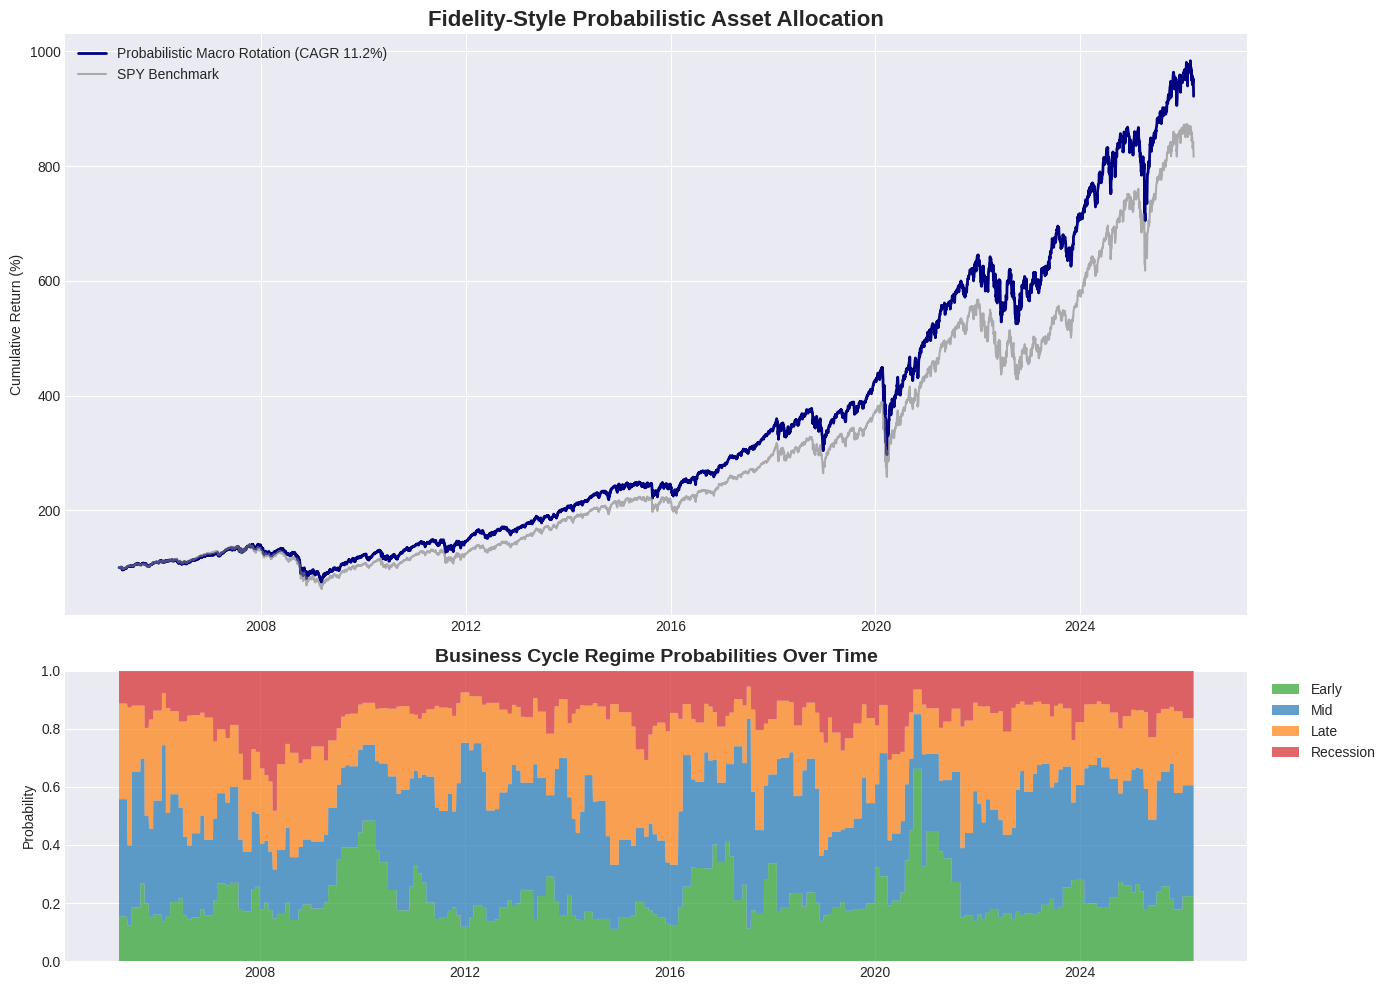

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5' # ★ 본인의 키로 변경!
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 FRED 매크로 데이터 로드 (피델리티 5대 핵심 요인 반영)
# ==============================================================================
print("=== 🌍 1단계: 피델리티 5대 핵심 거시 지표 다운로드 및 가공 ===")
try:
    # 1. 기업 활동 (Activity): 산업생산지수
    s_indpro = fred.get_series('INDPRO')
    # 2. 신용 사이클 (Credit): 하이일드 채권 스프레드
    s_hy = fred.get_series('BAMLH0A0HYM2')
    # 3. 재고 사이클 (Inventory): 총기업 재고 대 판매 비율
    s_isratio = fred.get_series('ISRATIO')
    # 4. 고용 상황 (Employment): 비농업부문 고용자수
    s_payems = fred.get_series('PAYEMS')
    # 5. 통화 정책 (Policy): 장단기 금리차 (10년물 - 2년물)
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_hy, s_isratio, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['INDPRO', 'HY_Spread', 'ISRATIO', 'PAYEMS', 'T10Y2Y']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 모멘텀(추세) 계산: 최근 3개월 평균의 변화량 등
    df_macro['Growth_Mom'] = (df_macro['INDPRO'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['HY_Spread'].diff(3)
    df_macro['Inventory_Mom'] = df_macro['ISRATIO'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['PAYEMS'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['T10Y2Y'].diff(3)

    # Z-Score (표준화): 지표들의 단위를 맞추기 위해 과거 60개월(5년) 롤링 표준화 적용 (Look-ahead Bias 방지)
    features = ['Growth_Mom', 'Credit_Mom', 'Inventory_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

    # 💡 [핵심] 피델리티 국면별 이상적인 Z-Score 벡터 정의
    # (성장, 신용, 재고, 고용, 통화정책 모멘텀의 이상적 부호와 강도)
    regime_vectors = {
        'Early': np.array([ 1.5, -1.0, -1.0,  1.0,  1.0]), # 성장폭발, 신용개선, 재고감소, 고용회복, 금리차확대
        'Mid':   np.array([ 0.5,  0.0,  0.0,  0.5, -0.5]), # 안정성장, 신용유지, 재고유지, 고용안정, 금리차축소
        'Late':  np.array([-1.0,  1.0,  1.0, -0.5, -1.0]), # 성장둔화, 신용경색, 재고증가, 고용둔화, 금리차역전
        'Recession': np.array([-2.0,  2.0, -1.0, -2.0,  1.5]) # 역성장, 신용위기, 재고급락, 대량해고, 급격한금리인하
    }

    # 각 월별로 4개 국면과의 '유사도(확률)' 계산
    prob_records = []
    for date, row in df_z.iterrows():
        current_vector = row.values
        distances = {}
        for regime, ideal_vector in regime_vectors.items():
            # 유클리디안 거리 계산
            dist = np.linalg.norm(current_vector - ideal_vector)
            distances[regime] = dist

        # 거리가 가까울수록(작을수록) 높은 확률을 가지도록 역수 취합 및 정규화
        inv_distances = {k: 1 / (v + 1e-6) for k, v in distances.items()}
        total_inv = sum(inv_distances.values())
        probs = {k: v / total_inv for k, v in inv_distances.items()}
        prob_records.append(probs)

    df_probs = pd.DataFrame(prob_records, index=df_z.index)
    print(" -> 5대 요인 기반 확률적 국면 판별 완료!\n")
except Exception as e:
    print(f"매크로 데이터 오류: {e}")
    raise SystemExit("데이터를 불러오지 못했습니다.")

# ==============================================================================
# 2. 📈 가격 데이터 준비 및 포트폴리오 룰 세팅
# ==============================================================================
print("=== 📈 2단계: ETF 데이터 로드 및 확률적 비중 배분 준비 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SHY', 'IEF', 'GLD', 'SPY', 'RSP']
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=21)

etf_data = yf.download(all_tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = max(etf_px.index[0], df_probs.index[0] + pd.DateOffset(months=1))
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (확률 비례 블렌딩 + Drift 반영 수수료 현실화)
# ==============================================================================
print("=== ⚙️ 3단계: 매크로 확률 비례 자산배분 실행 (실무적 수수료 적용) ===")
weights_at_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)
eom_dates = etf_px.groupby([etf_px.index.year, etf_px.index.month]).tail(1).index
transaction_fee_rate = 0.002

for date in etf_px.index:
    idx = etf_px.index.get_loc(date)
    if date not in eom_dates:
        if idx > 0: weights_at_daily.loc[date] = weights_at_daily.iloc[idx - 1]
        continue

    # 발표 시차(Publication Lag)를 고려하여 2개월 전 데이터의 확률 참조 (Look-ahead Bias 완벽 차단)
    macro_date_mask = df_probs.index <= (date - pd.DateOffset(months=1))

    if len(df_probs[macro_date_mask]) > 0:
        current_probs = df_probs[macro_date_mask].iloc[-1]

        # 💡 [핵심] 국면별 확률에 비례하여 섹터 비중을 부드럽게 섞음 (Blending)
        candidate_weights = pd.Series(0.0, index=etf_px.columns)
        for regime, prob in current_probs.items():
            sectors = cycle_playbook.get(regime, ['SPY'])
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                candidate_weights[s] += weight_per_sector

        weights_at_daily.loc[date] = candidate_weights
    else:
        weights_at_daily.loc[date, 'SPY'] = 1.0

# Drift 시뮬레이션 및 Turnover 수수료 계산
real_weights = weights_at_daily.copy()
for i in range(1, len(etf_px)):
    drifted_w = real_weights.iloc[i-1] * (1 + daily_returns.iloc[i])
    if drifted_w.sum() > 0: drifted_w = drifted_w / drifted_w.sum()
    if real_weights.index[i] not in eom_dates:
        real_weights.iloc[i] = drifted_w

turnover = (weights_at_daily - real_weights.shift(1).fillna(0)).abs().sum(axis=1)
daily_costs = turnover * transaction_fee_rate

net_daily_return = (weights_at_daily.shift(1).fillna(0) * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()

spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 📊 결과 시각화 (수익률 + 국면 확률 차트)
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과: CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# [상단] 누적 수익률 차트
ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'Probabilistic Macro Rotation (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('Fidelity-Style Probabilistic Asset Allocation', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# [하단] 국면 확률 변화 (Area Chart)
# 확률 데이터를 ETF 날짜 기준 월말로 리샘플링하여 매핑
probs_aligned = df_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.7)
ax2.set_title('Business Cycle Regime Probabilities Over Time', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

=== 🤖 1단계: 머신러닝(K-Means)이 과거 데이터를 학습하여 국면 자동 분류 ===

[AI가 도출한 국면별 데이터 특징 (Centroids)]
 - Mid: 성장 0.10, 신용경색 -0.07, 고용 0.27
 - Early: 성장 0.76, 신용경색 -0.51, 고용 0.31
 - Late: 성장 -0.87, 신용경색 0.54, 고용 -0.94
 - Recession: 성장 -3.54, 신용경색 3.83, 고용 -4.24

 -> 머신러닝 군집화 및 확률 산출 완료!

=== 📈 2단계: ETF 데이터 로드 및 확률적 비중 배분 준비 ===
=== ⚙️ 3단계: AI 매크로 확률 비례 자산배분 실행 (실무적 수수료 적용) ===

🏆 최종 성과: CAGR 10.93% | MDD -47.52% | 누적수수료 21.32%


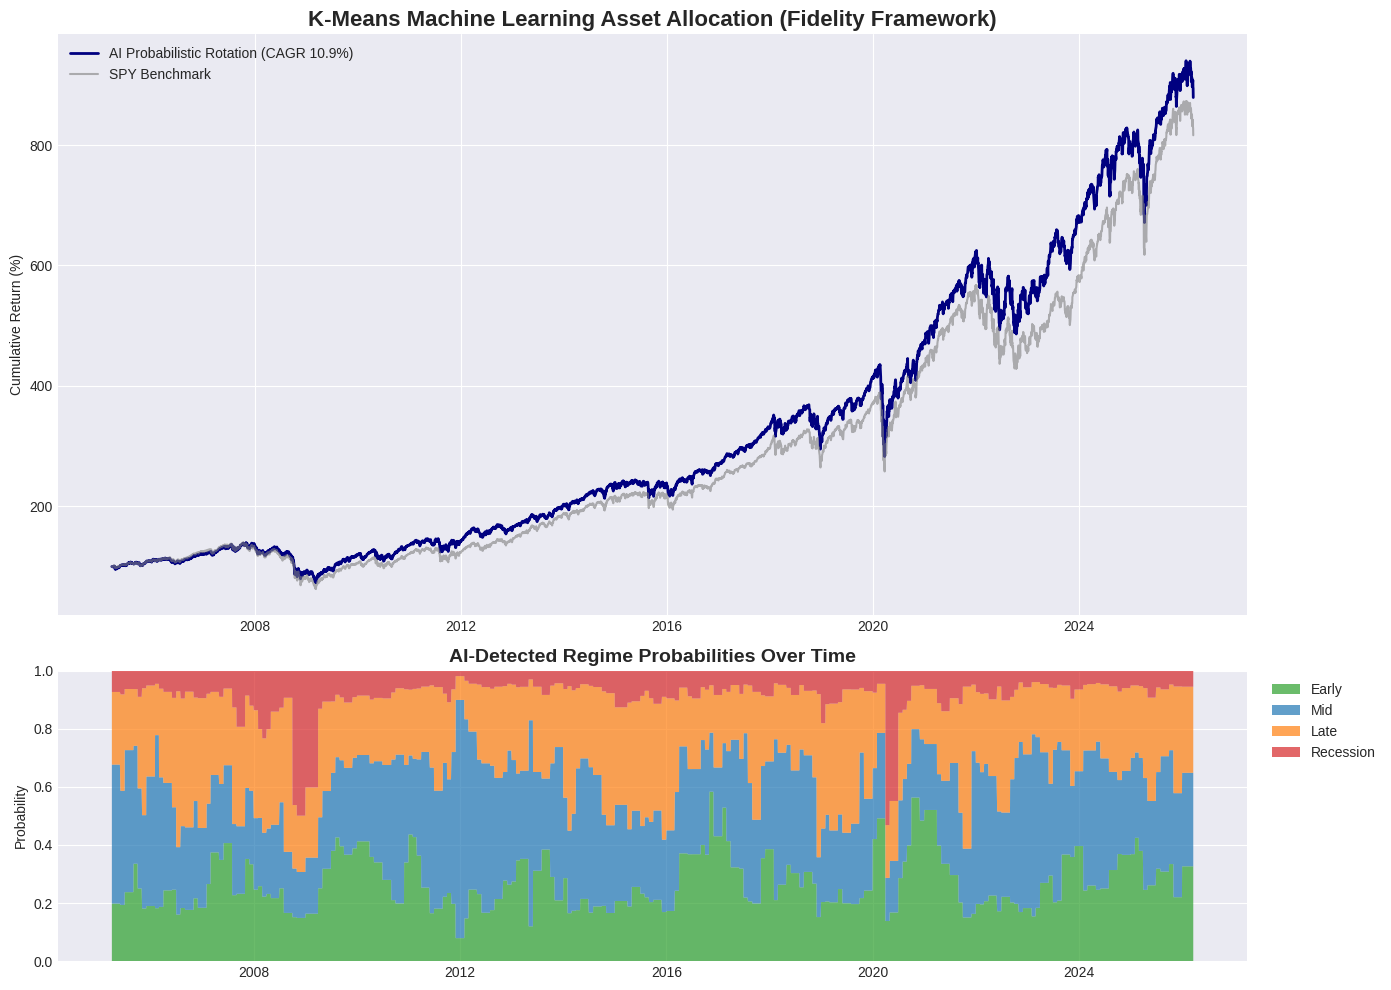

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5' # ★ 본인의 키로 변경!
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 머신러닝 학습 (K-Means Clustering)
# ==============================================================================
print("=== 🤖 1단계: 머신러닝(K-Means)이 과거 데이터를 학습하여 국면 자동 분류 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_hy = fred.get_series('BAMLH0A0HYM2')
    s_isratio = fred.get_series('ISRATIO')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_hy, s_isratio, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Inventory', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 모멘텀 계산
    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Inventory_Mom'] = df_macro['Inventory'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # Z-Score (표준화)
    features = ['Growth_Mom', 'Credit_Mom', 'Inventory_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

    # 💡 [핵심] 사람이 정한 숫자 대신, K-Means 알고리즘으로 4개의 군집(Cluster) 생성
    kmeans = KMeans(n_clusters=4, random_state=42)
    kmeans.fit(df_z)

    # 4개 군집의 중심점(Centroids) 추출
    centroids = kmeans.cluster_centers_

    # [라벨링 자동화] 군집 0,1,2,3을 경제 논리에 맞게 Early/Mid/Late/Recession으로 매핑
    # '경제 건전성 점수' = (성장 + 고용) - 신용위험
    # 점수가 가장 높으면 Early, 가장 낮으면 Recession으로 모델이 자동 할당합니다.
    health_scores = centroids[:, 0] + centroids[:, 3] - centroids[:, 1]
    sorted_idx = np.argsort(health_scores)[::-1] # 내림차순 정렬

    regime_map = {
        sorted_idx[0]: 'Early',
        sorted_idx[1]: 'Mid',
        sorted_idx[2]: 'Late',
        sorted_idx[3]: 'Recession'
    }

    print("\n[AI가 도출한 국면별 데이터 특징 (Centroids)]")
    for i in range(4):
        print(f" - {regime_map[i]}: 성장 {centroids[i][0]:.2f}, 신용경색 {centroids[i][1]:.2f}, 고용 {centroids[i][3]:.2f}")

    # 각 월별로 각 중심점(국면)까지의 거리를 계산하여 확률로 변환
    distances = kmeans.transform(df_z) # (월 개수, 4개의 국면까지의 거리)
    prob_records = []

    for i in range(len(df_z)):
        dist_row = distances[i]
        # 거리가 가까울수록 확률이 높아야 하므로 역수 적용
        inv_dist = 1 / (dist_row + 1e-6)
        probs = inv_dist / inv_dist.sum()

        # 클러스터 인덱스를 경제 국면 이름으로 매핑
        prob_dict = {regime_map[j]: probs[j] for j in range(4)}
        prob_records.append(prob_dict)

    df_probs = pd.DataFrame(prob_records, index=df_z.index)
    print("\n -> 머신러닝 군집화 및 확률 산출 완료!\n")

except Exception as e:
    print(f"매크로 데이터 오류: {e}")
    raise SystemExit("데이터를 불러오지 못했습니다.")

# ==============================================================================
# 2. 📈 가격 데이터 준비 및 포트폴리오 룰 세팅
# ==============================================================================
print("=== 📈 2단계: ETF 데이터 로드 및 확률적 비중 배분 준비 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SHY', 'IEF', 'GLD', 'SPY']
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=21)

etf_data = yf.download(all_tickers, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = max(etf_px.index[0], df_probs.index[0] + pd.DateOffset(months=1))
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (확률 비례 블렌딩 + 1개월 Lag 반영)
# ==============================================================================
print("=== ⚙️ 3단계: AI 매크로 확률 비례 자산배분 실행 (실무적 수수료 적용) ===")
weights_at_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)
eom_dates = etf_px.groupby([etf_px.index.year, etf_px.index.month]).tail(1).index
transaction_fee_rate = 0.002

for date in etf_px.index:
    idx = etf_px.index.get_loc(date)
    if date not in eom_dates:
        if idx > 0: weights_at_daily.loc[date] = weights_at_daily.iloc[idx - 1]
        continue

    # ★ 실무 최적화: 1개월 전(T-1) 데이터까지만 참조하여 Look-ahead Bias 방어
    macro_date_mask = df_probs.index <= (date - pd.DateOffset(months=1))

    if len(df_probs[macro_date_mask]) > 0:
        current_probs = df_probs[macro_date_mask].iloc[-1]
        candidate_weights = pd.Series(0.0, index=etf_px.columns)

        for regime, prob in current_probs.items():
            sectors = cycle_playbook.get(regime, ['SPY'])
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                candidate_weights[s] += weight_per_sector

        weights_at_daily.loc[date] = candidate_weights
    else:
        weights_at_daily.loc[date, 'SPY'] = 1.0

# Drift 시뮬레이션 및 Turnover 수수료 계산
real_weights = weights_at_daily.copy()
for i in range(1, len(etf_px)):
    drifted_w = real_weights.iloc[i-1] * (1 + daily_returns.iloc[i])
    if drifted_w.sum() > 0: drifted_w = drifted_w / drifted_w.sum()
    if real_weights.index[i] not in eom_dates:
        real_weights.iloc[i] = drifted_w

turnover = (weights_at_daily - real_weights.shift(1).fillna(0)).abs().sum(axis=1)
daily_costs = turnover * transaction_fee_rate

net_daily_return = (weights_at_daily.shift(1).fillna(0) * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()

spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 📊 결과 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과: CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# [상단] 누적 수익률 차트
ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'AI Probabilistic Rotation (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('K-Means Machine Learning Asset Allocation (Fidelity Framework)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# [하단] 국면 확률 변화 (Area Chart)
probs_aligned = df_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.7)
ax2.set_title('AI-Detected Regime Probabilities Over Time', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [5]:
import seaborn as sns
from sklearn.decomposition import PCA

# ==============================================================================
# 💡 [추가] K-Means 군집화 시각화 (PCA 2차원 축소 및 히트맵)
# (이 코드를 기존 코드의 kmeans.fit() 이후에 추가하세요)
# ==============================================================================
print("=== 📊 군집 시각화 및 특징 분석 차트 생성 중 ===")

# 1. 차원 축소: 5차원 매크로 데이터를 2차원으로 압축 (시각화를 위함)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_train) # 학습 데이터(1970~1999) 기준

# 중심점(Centroids)도 동일하게 2차원으로 변환
pca_centroids = pca.transform(centroids)

# 시각화를 위한 데이터프레임 구성
df_pca = pd.DataFrame(data=pca_features, columns=['PC1 (Growth & Emp)', 'PC2 (Credit & Policy)'])
df_pca['Cluster'] = kmeans.labels_
# 클러스터 번호를 우리가 부여한 국면 이름(Early, Mid 등)으로 매핑
df_pca['Regime'] = df_pca['Cluster'].map(regime_map)

# 2. 중심점(Centroids) 특징 데이터프레임 (히트맵용)
df_centroids = pd.DataFrame(centroids, columns=features)
df_centroids.index = [regime_map[i] for i in range(4)]
# 논리적 흐름(Early -> Mid -> Late -> Recession)으로 정렬
df_centroids = df_centroids.reindex(['Early', 'Mid', 'Late', 'Recession'])

# ---------------------------------------------------------
# 차트 그리기 (1x2 형태의 깔끔한 대시보드)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# [차트 1] PCA 2차원 산점도 (데이터들이 어떻게 뭉쳐있는가?)
sns.scatterplot(x='PC1 (Growth & Emp)', y='PC2 (Credit & Policy)',
                hue='Regime', style='Regime', palette='bright',
                data=df_pca, alpha=0.6, s=50, ax=ax1)

# 중심점(Centroid)을 거대한 'X' 마크로 표시
ax1.scatter(pca_centroids[:, 0], pca_centroids[:, 1],
            s=300, c='black', marker='X', linewidths=2, label='Centroids', zorder=10)

ax1.set_title('K-Means Clustering Result (2D PCA Projection)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend(title='Business Cycle Regime')
ax1.grid(True, linestyle='--', alpha=0.7)

# [차트 2] 각 국면별 매크로 지표 특징 (Heatmap)
sns.heatmap(df_centroids.T, annot=True, cmap='RdBu_r', center=0,
            fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8}, ax=ax2)

ax2.set_title('Macro Factors Z-Score by Regime (Centroids)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Identified Regime')
ax2.set_ylabel('Macro Indicators')

plt.tight_layout()
plt.show()

=== 📊 군집 시각화 및 특징 분석 차트 생성 중 ===


NameError: name 'df_train' is not defined

=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 과거 위기 선행 학습 ===

[AI가 1980~1999년 과거 위기에서 학습한 국면별 특징]
 - Late: 성장 -0.27, 공장가동 -0.11, 신용위험 0.41
 - Early: 성장 0.93, 공장가동 0.69, 신용위험 -0.70
 - Mid: 성장 0.31, 공장가동 0.52, 신용위험 -0.31
 - Recession: 성장 -1.24, 공장가동 -1.29, 신용위험 1.01

 -> 초장기 머신러닝 학습 및 확률 산출 완료!

=== 📈 2단계: ETF 실전 투자 데이터 로드 (Out-of-Sample) ===
=== ⚙️ 3단계: AI 매크로 확률 비례 자산배분 실행 (1개월 Lag 적용) ===

🏆 최종 성과 (2000년~현재): CAGR 7.89% | MDD -46.64% | 누적수수료 29.45%


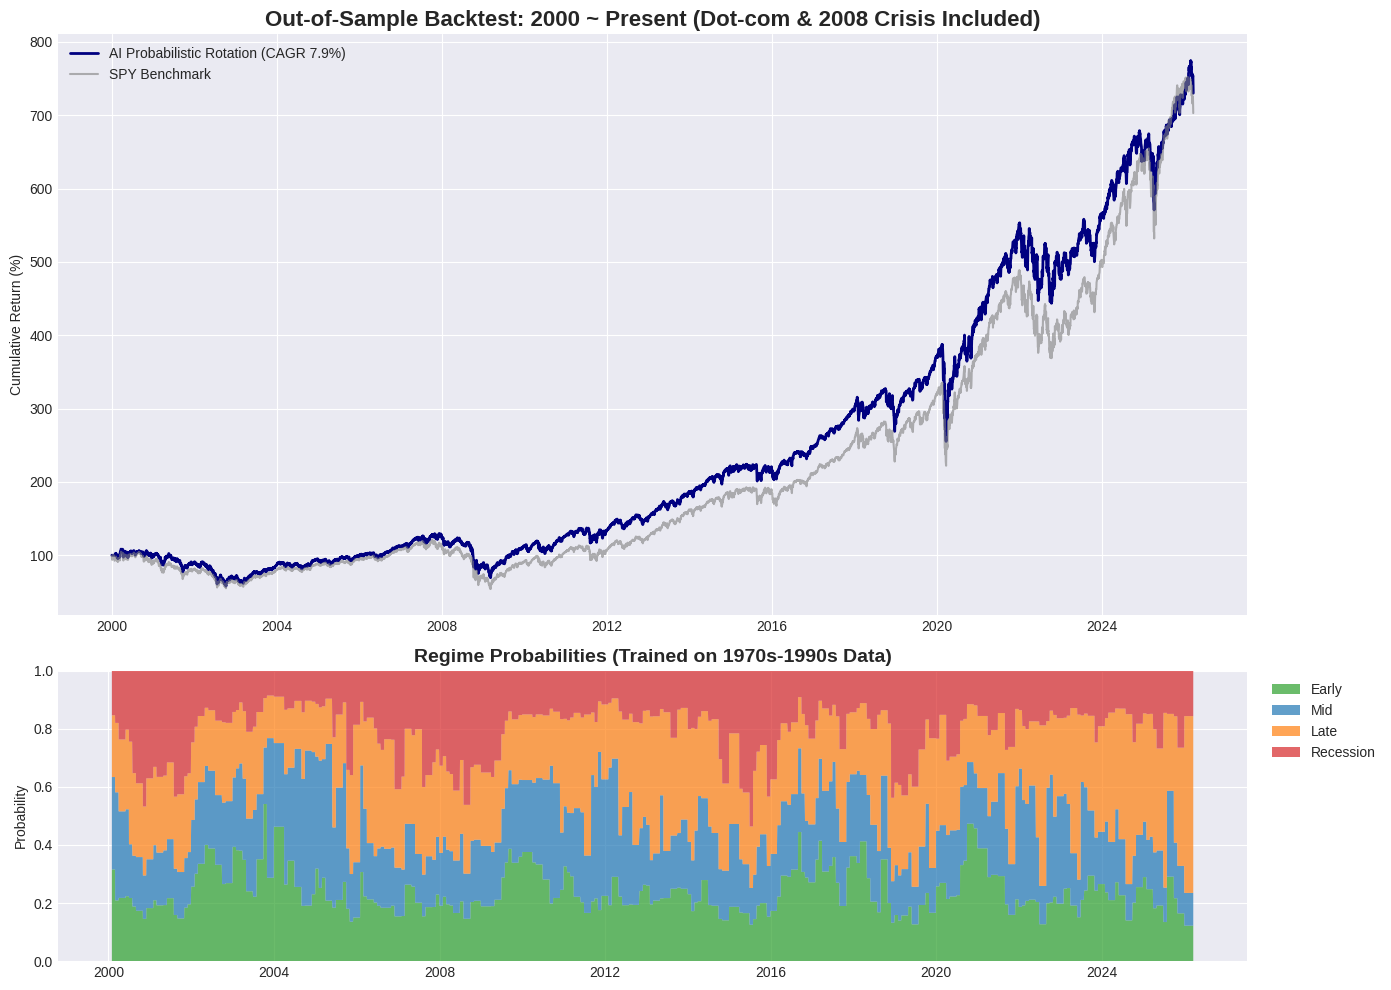

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5' # ★ 본인의 키로 변경!
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 AI 선행 학습 (1976년 ~ 1999년 In-Sample)
# ==============================================================================
print("=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 과거 위기 선행 학습 ===")
try:
    # 지표 교체: 역사가 짧은 ETF 시대 지표를 과거부터 존재한 본질적 지표로 스왑
    s_indpro = fred.get_series('INDPRO')    # 성장
    s_baa = fred.get_series('BAA10Y')       # 신용 위험 (1953년~) - 하이일드 대체
    s_tcu = fred.get_series('TCU')          # 산업 가동률 (1967년~) - 재고 대 판매 역지수(대체)
    s_payems = fred.get_series('PAYEMS')    # 고용
    s_t10y2y = fred.get_series('T10Y2Y')    # 통화 정책 (1976년~)

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 모멘텀 계산 (추세)
    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3) # 가동률 증가는 수요 폭발(재고 감소)을 의미
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # Z-Score (과거 60개월 롤링 표준화 적용하여 Look-ahead Bias 방지)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna() # 롤링 때문에 대략 1981년부터 데이터가 유효해짐

    # 💡 [핵심] In-Sample (학습 기간) 분리: 1999년 말까지만 AI에게 정답지로 제공
    df_train = df_z.loc[:'1999-12-31']

    kmeans = KMeans(n_clusters=4, random_state=42)
    kmeans.fit(df_train) # 1980년대 오일쇼크, 90년대 침체기를 학습
    centroids = kmeans.cluster_centers_

    # 국면 라벨링 자동화 (가동률 상승, 성장 상승, 신용 위험 하락 = 좋은 국면)
    health_scores = centroids[:, 0] + centroids[:, 2] + centroids[:, 3] - centroids[:, 1]
    sorted_idx = np.argsort(health_scores)[::-1]

    regime_map = {
        sorted_idx[0]: 'Early',
        sorted_idx[1]: 'Mid',
        sorted_idx[2]: 'Late',
        sorted_idx[3]: 'Recession'
    }

    print("\n[AI가 1980~1999년 과거 위기에서 학습한 국면별 특징]")
    for i in range(4):
        print(f" - {regime_map[i]}: 성장 {centroids[i][0]:.2f}, 공장가동 {centroids[i][2]:.2f}, 신용위험 {centroids[i][1]:.2f}")

    # 전체 기간(1980년대 ~ 현재)에 대해 학습된 기준점과의 거리를 확률로 산출
    distances = kmeans.transform(df_z)
    prob_records = []

    for i in range(len(df_z)):
        inv_dist = 1 / (distances[i] + 1e-6)
        probs = inv_dist / inv_dist.sum()
        prob_dict = {regime_map[j]: probs[j] for j in range(4)}
        prob_records.append(prob_dict)

    df_probs = pd.DataFrame(prob_records, index=df_z.index)
    print("\n -> 초장기 머신러닝 학습 및 확률 산출 완료!\n")

except Exception as e:
    print(f"매크로 데이터 오류: {e}")
    raise SystemExit("데이터를 불러오지 못했습니다.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (1998년 말 ETF 상장 직후부터)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 (Out-of-Sample) ===")
# 2000년대 초반 나스닥 버블 테스트를 위해 상장일이 가장 빠른 10개 핵심 섹터만 사용
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 실전 투자는 2000년 1월 1일부터 시작 (닷컴버블 직전)
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (실전: 2000년 ~ 현재)
# ==============================================================================
print("=== ⚙️ 3단계: AI 매크로 확률 비례 자산배분 실행 (1개월 Lag 적용) ===")
weights_at_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)
eom_dates = etf_px.groupby([etf_px.index.year, etf_px.index.month]).tail(1).index
transaction_fee_rate = 0.002

for date in etf_px.index:
    idx = etf_px.index.get_loc(date)
    if date not in eom_dates:
        if idx > 0: weights_at_daily.loc[date] = weights_at_daily.iloc[idx - 1]
        continue

    # 실무 최적화: 1개월 전(T-1) 데이터까지만 참조
    macro_date_mask = df_probs.index <= (date - pd.DateOffset(months=1))

    if len(df_probs[macro_date_mask]) > 0:
        current_probs = df_probs[macro_date_mask].iloc[-1]
        candidate_weights = pd.Series(0.0, index=etf_px.columns)

        for regime, prob in current_probs.items():
            sectors = cycle_playbook.get(regime, ['SPY'])
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                candidate_weights[s] += weight_per_sector

        weights_at_daily.loc[date] = candidate_weights
    else:
        weights_at_daily.loc[date, 'SPY'] = 1.0

# Drift 시뮬레이션 및 Turnover 수수료 계산
real_weights = weights_at_daily.copy()
for i in range(1, len(etf_px)):
    drifted_w = real_weights.iloc[i-1] * (1 + daily_returns.iloc[i])
    if drifted_w.sum() > 0: drifted_w = drifted_w / drifted_w.sum()
    if real_weights.index[i] not in eom_dates:
        real_weights.iloc[i] = drifted_w

turnover = (weights_at_daily - real_weights.shift(1).fillna(0)).abs().sum(axis=1)
daily_costs = turnover * transaction_fee_rate

net_daily_return = (weights_at_daily.shift(1).fillna(0) * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()

spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 📊 결과 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과 (2000년~현재): CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'AI Probabilistic Rotation (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('Out-of-Sample Backtest: 2000 ~ Present (Dot-com & 2008 Crisis Included)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

probs_aligned = df_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.7)
ax2.set_title('Regime Probabilities (Trained on 1970s-1990s Data)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

# train model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정 (★ 본인의 FRED API 키로 반드시 변경하세요)
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 초기 AI 선행 학습 (1976년 ~ 1999년 In-Sample)
# ==============================================================================
print("=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 전처리 ===")
try:
    # 1970년대 스태그플레이션까지 포함하기 위해 장기 지표로 스왑(Proxy)
    s_indpro = fred.get_series('INDPRO')    # 성장
    s_baa = fred.get_series('BAA10Y')       # 신용 위험 (1953년~) - 하이일드 대체
    s_tcu = fred.get_series('TCU')          # 산업 가동률 (1967년~) - 재고 역지수 대체
    s_payems = fred.get_series('PAYEMS')    # 고용
    s_t10y2y = fred.get_series('T10Y2Y')    # 통화 정책 (1976년~)

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 모멘텀 계산 (추세 반영)
    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # Z-Score (과거 60개월 롤링 표준화 적용하여 Look-ahead Bias 완벽 차단)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna() # 롤링 적용 후 대략 1981년부터 데이터 유효

    # [초기 모델 구축] 1999년 말까지만 AI에게 정답지로 제공 (시각화 목적)
    df_train_initial = df_z.loc[:'1999-12-31']

    kmeans_init = KMeans(n_clusters=4, random_state=42)
    kmeans_init.fit(df_train_initial)
    centroids_init = kmeans_init.cluster_centers_

    # 국면 라벨링 자동화 로직
    health_scores = centroids_init[:, 0] + centroids_init[:, 2] + centroids_init[:, 3] - centroids_init[:, 1]
    sorted_idx = np.argsort(health_scores)[::-1]

    regime_map_init = {
        sorted_idx[0]: 'Early',
        sorted_idx[1]: 'Mid',
        sorted_idx[2]: 'Late',
        sorted_idx[3]: 'Recession'
    }

except Exception as e:
    print(f"매크로 데이터 오류: {e}")
    raise SystemExit("데이터를 불러오지 못했습니다. API 키를 확인하세요.")

# ==============================================================================
# 2. 📊 군집 시각화 및 특징 분석 (보고서용 차트)
# ==============================================================================
print("=== 📊 2단계: AI 초기 군집화 시각화 (PCA & Heatmap) ===")

pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_train_initial)
pca_centroids = pca.transform(centroids_init)

df_pca = pd.DataFrame(data=pca_features, columns=['PC1 (Growth & Emp)', 'PC2 (Credit & Policy)'])
df_pca['Cluster'] = kmeans_init.labels_
df_pca['Regime'] = df_pca['Cluster'].map(regime_map_init)

df_centroids = pd.DataFrame(centroids_init, columns=features)
df_centroids.index = [regime_map_init[i] for i in range(4)]
df_centroids = df_centroids.reindex(['Early', 'Mid', 'Late', 'Recession'])

fig_vis, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 산점도
sns.scatterplot(x='PC1 (Growth & Emp)', y='PC2 (Credit & Policy)',
                hue='Regime', style='Regime', palette='bright',
                data=df_pca, alpha=0.6, s=50, ax=ax1)
ax1.scatter(pca_centroids[:, 0], pca_centroids[:, 1],
            s=300, c='black', marker='X', linewidths=2, label='Centroids', zorder=10)
ax1.set_title('K-Means Clustering Result (1981-1999 Data)', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 히트맵
sns.heatmap(df_centroids.T, annot=True, cmap='RdBu_r', center=0,
            fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8}, ax=ax2)
ax2.set_title('Macro Factors Z-Score by Regime', fontsize=14, fontweight='bold')
ax2.set_xlabel('Identified Regime')
ax2.set_ylabel('Macro Indicators')

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. 📈 가격 데이터 로드 및 피델리티 플레이북 세팅
# ==============================================================================
print("=== 📈 3단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 4. ⚙️ 백테스트 (Expanding Window - 매월 AI 재학습 및 진화)
# ==============================================================================
print("=== ⚙️ 4단계: Expanding Window 기반 실시간 AI 진화형 백테스트 실행 ===")
weights_at_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)
eom_dates = etf_px.groupby([etf_px.index.year, etf_px.index.month]).tail(1).index
transaction_fee_rate = 0.002

dynamic_probs_list = [] # 매월 진화하는 국면 확률 기록용

for date in etf_px.index:
    idx = etf_px.index.get_loc(date)

    if date not in eom_dates:
        if idx > 0: weights_at_daily.loc[date] = weights_at_daily.iloc[idx - 1]
        continue

    # [핵심] 리밸런싱 시점(T) 기준 1개월 전(T-1)까지의 데이터로 무한 재학습
    train_end_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:train_end_date]

    if len(df_train_current) > 60:
        # 매월 K-Means 새롭게 피팅
        kmeans_dynamic = KMeans(n_clusters=4, random_state=42)
        kmeans_dynamic.fit(df_train_current)
        centroids_dynamic = kmeans_dynamic.cluster_centers_

        # 중심점 동적 라벨링
        health_scores = centroids_dynamic[:, 0] + centroids_dynamic[:, 2] + centroids_dynamic[:, 3] - centroids_dynamic[:, 1]
        sorted_idx = np.argsort(health_scores)[::-1]
        regime_map_dynamic = {
            sorted_idx[0]: 'Early', sorted_idx[1]: 'Mid',
            sorted_idx[2]: 'Late', sorted_idx[3]: 'Recession'
        }

        # 최신 1개월 데이터의 국면 확률 계산
        current_data = df_train_current.iloc[-1:].values
        distances = kmeans_dynamic.transform(current_data)[0]

        inv_dist = 1 / (distances + 1e-6)
        probs = inv_dist / inv_dist.sum()
        current_probs = {regime_map_dynamic[j]: probs[j] for j in range(4)}

        # 확률 기록
        dynamic_prob_record = current_probs.copy()
        dynamic_prob_record['Date'] = date
        dynamic_probs_list.append(dynamic_prob_record)

        # 비중 배분 (Blending)
        candidate_weights = pd.Series(0.0, index=etf_px.columns)
        for regime, prob in current_probs.items():
            sectors = cycle_playbook.get(regime, ['SPY'])
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                candidate_weights[s] += weight_per_sector

        weights_at_daily.loc[date] = candidate_weights

    else:
        weights_at_daily.loc[date, 'SPY'] = 1.0

# DataFrame 변환 및 Drift / Turnover 연산
df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

real_weights = weights_at_daily.copy()
for i in range(1, len(etf_px)):
    drifted_w = real_weights.iloc[i-1] * (1 + daily_returns.iloc[i])
    if drifted_w.sum() > 0: drifted_w = drifted_w / drifted_w.sum()
    if real_weights.index[i] not in eom_dates:
        real_weights.iloc[i] = drifted_w

turnover = (weights_at_daily - real_weights.shift(1).fillna(0)).abs().sum(axis=1)
daily_costs = turnover * transaction_fee_rate

net_daily_return = (weights_at_daily.shift(1).fillna(0) * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()
spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 5. 🚀 최종 성과 및 동적 확률 변화 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과 (2000년~현재): CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

fig_backtest, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax3.plot(port_cum_return.index, port_cum_return * 100, label=f'AI Expanding Window Rotation (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
ax3.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax3.set_title('Out-of-Sample Backtest: Expanding Window (2000 ~ Present)', fontsize=16, fontweight='bold')
ax3.set_ylabel('Cumulative Return (%)')
ax3.legend(loc='upper left')

# 일별 인덱스에 맞춰 동적 확률 데이터 리인덱싱
probs_aligned = df_dynamic_probs.reindex(port_cum_return.index).ffill().dropna()

ax4.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.7)
ax4.set_title('Dynamic Regime Probabilities (Updated Monthly)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Probability')
ax4.set_ylim(0, 1)
ax4.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture # ★ K-Means 대신 GMM 임포트
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정 (★ 본인의 FRED API 키로 반드시 변경하세요)
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Proxy 지표 사용)
# ==============================================================================
print("=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')    # 성장
    s_baa = fred.get_series('BAA10Y')       # 신용 위험
    s_tcu = fred.get_series('TCU')          # 산업 가동률 (재고 역지수)
    s_payems = fred.get_series('PAYEMS')    # 고용
    s_t10y2y = fred.get_series('T10Y2Y')    # 통화 정책

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 모멘텀 계산 (3개월 추세 변화량)
    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # Z-Score (과거 60개월 롤링 표준화)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"매크로 데이터 오류: {e}")
    raise SystemExit("데이터를 불러오지 못했습니다. API 키를 확인하세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (실전 투자: 2000년 ~ 현재)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 피델리티 플레이북
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (GMM 엔진 + Expanding Window 적용)
# ==============================================================================
print("=== ⚙️ 3단계: GMM 기반 확률적 국면 배분 백테스트 실행 ===")
weights_at_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)
eom_dates = etf_px.groupby([etf_px.index.year, etf_px.index.month]).tail(1).index
transaction_fee_rate = 0.002

dynamic_probs_list = []

for date in etf_px.index:
    idx = etf_px.index.get_loc(date)

    if date not in eom_dates:
        if idx > 0: weights_at_daily.loc[date] = weights_at_daily.iloc[idx - 1]
        continue

    # 1개월 전(T-1) 데이터까지만 참조하여 GMM 무한 재학습
    train_end_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:train_end_date]

    if len(df_train_current) > 60:
        # 💡 [핵심] K-Means 대신 GMM(Gaussian Mixture Model) 적용
        # covariance_type='full' : 타원형의 자유로운 분포(안개)를 허용
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)

        # GMM의 중심점(means_) 추출
        centroids_dynamic = gmm.means_

        # 중심점 동적 라벨링 (경제 건전성 스코어)
        health_scores = centroids_dynamic[:, 0] + centroids_dynamic[:, 2] + centroids_dynamic[:, 3] - centroids_dynamic[:, 1]
        sorted_idx = np.argsort(health_scores)[::-1]
        regime_map_dynamic = {
            sorted_idx[0]: 'Early', sorted_idx[1]: 'Mid',
            sorted_idx[2]: 'Late', sorted_idx[3]: 'Recession'
        }

        # 💡 [핵심] 억지 거리가 아닌, 통계적으로 완벽한 'Soft 확률' 추출 (predict_proba)
        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]

        # 클러스터 인덱스에 맞게 확률 매핑
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        # 확률 기록
        dynamic_prob_record = current_probs.copy()
        dynamic_prob_record['Date'] = date
        dynamic_probs_list.append(dynamic_prob_record)

        # 확률 기반 섹터 비중 배분 (Blending)
        candidate_weights = pd.Series(0.0, index=etf_px.columns)
        for regime, prob in current_probs.items():
            sectors = cycle_playbook.get(regime, ['SPY'])
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                candidate_weights[s] += weight_per_sector

        weights_at_daily.loc[date] = candidate_weights

    else:
        weights_at_daily.loc[date, 'SPY'] = 1.0

# DataFrame 변환 및 Drift / Turnover 연산
df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

real_weights = weights_at_daily.copy()
for i in range(1, len(etf_px)):
    drifted_w = real_weights.iloc[i-1] * (1 + daily_returns.iloc[i])
    if drifted_w.sum() > 0: drifted_w = drifted_w / drifted_w.sum()
    if real_weights.index[i] not in eom_dates:
        real_weights.iloc[i] = drifted_w

turnover = (weights_at_daily - real_weights.shift(1).fillna(0)).abs().sum(axis=1)
daily_costs = turnover * transaction_fee_rate

net_daily_return = (weights_at_daily.shift(1).fillna(0) * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()
spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 🚀 최종 성과 및 동적 확률 변화 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과 (2000년~현재): CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'GMM Probabilistic Rotation (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('Out-of-Sample Backtest: GMM Engine + Expanding Window', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 일별 인덱스에 맞춰 동적 확률 데이터 리인덱싱
probs_aligned = df_dynamic_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.7)
ax2.set_title('GMM Native Probabilities (Soft Clustering)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

# 🚀 [스무딩 적용본] GMM + 3개월 평균 (Fidelity Style)

=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 GMM 선행 학습 ===

[AI가 1980~1999년 과거 위기에서 학습한 국면별 특징]
 - Late: 성장 -0.58, 공장가동 0.27, 신용위험 0.97
 - Mid: 성장 0.21, 공장가동 0.09, 신용위험 -0.13
 - Early: 성장 0.33, 공장가동 0.55, 신용위험 -0.44
 - Recession: 성장 -1.40, 공장가동 -1.54, 신용위험 1.34

 -> 초장기 GMM 머신러닝 학습 및 스무딩 확률 산출 완료!

=== 📈 2단계: ETF 실전 투자 데이터 로드 (Out-of-Sample) ===
=== ⚙️ 3단계: AI 매크로 확률 비례 자산배분 실행 (1개월 Lag 적용) ===

🏆 최종 성과 (2000년~현재): CAGR 6.93% | MDD -80.08% | 누적수수료 7.88%


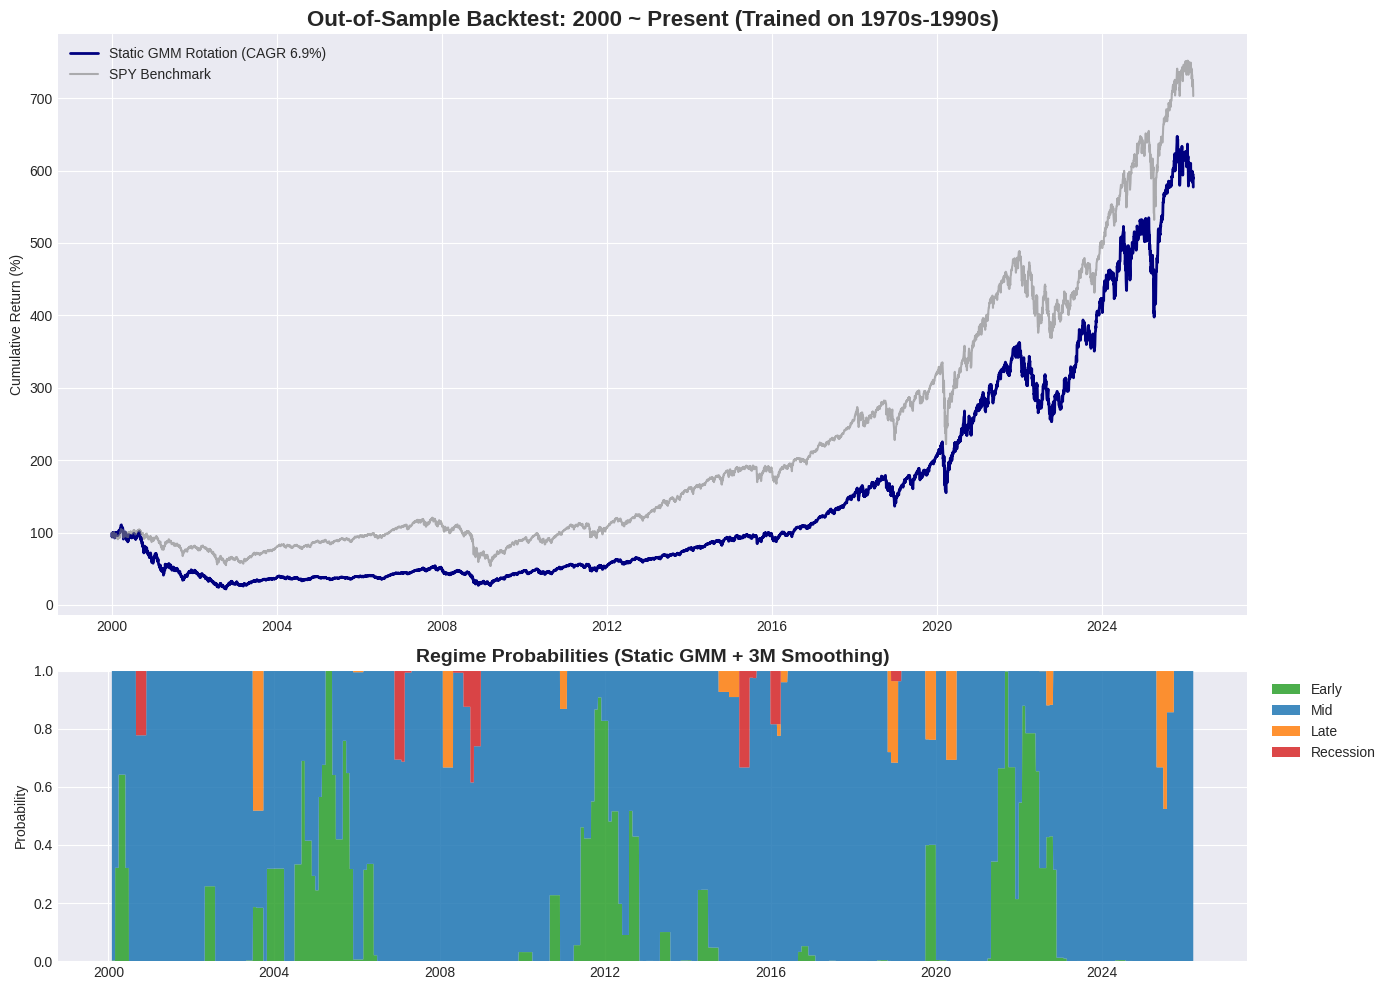

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import yfinance as yf
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5' # ★ 본인의 키 입력
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 AI 선행 학습 (1976년 ~ 1999년 In-Sample)
# ==============================================================================
print("=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 GMM 선행 학습 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

    # 💡 [핵심] In-Sample (학습 기간) 분리: 1999년 말까지만 정답지로 제공
    df_train = df_z.loc[:'1999-12-31']

    # K-Means 대신 GMM 적용하여 통계적 확률 획득
    gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
    gmm.fit(df_train)
    centroids = gmm.means_

    # 국면 라벨링
    health_scores = centroids[:, 0] + centroids[:, 2] + centroids[:, 3] - centroids[:, 1]
    sorted_idx = np.argsort(health_scores)[::-1]

    regime_map = {
        sorted_idx[0]: 'Early',
        sorted_idx[1]: 'Mid',
        sorted_idx[2]: 'Late',
        sorted_idx[3]: 'Recession'
    }

    print("\n[AI가 1980~1999년 과거 위기에서 학습한 국면별 특징]")
    for i in range(4):
        print(f" - {regime_map[i]}: 성장 {centroids[i][0]:.2f}, 공장가동 {centroids[i][2]:.2f}, 신용위험 {centroids[i][1]:.2f}")

    # 전체 기간(1980년대 ~ 현재)에 대해 GMM 수학적 확률 산출
    raw_probs = gmm.predict_proba(df_z)
    df_probs = pd.DataFrame(index=df_z.index)
    for i in range(4):
        df_probs[regime_map[i]] = raw_probs[:, i]

    # 💡 [추가 최적화] 확률에 3개월 스무딩을 적용하여 노이즈 제거
    df_probs = df_probs.rolling(3).mean().dropna()

    print("\n -> 초장기 GMM 머신러닝 학습 및 스무딩 확률 산출 완료!\n")

except Exception as e:
    print(f"매크로 데이터 오류: {e}")
    raise SystemExit("데이터를 불러오지 못했습니다.")

# ==============================================================================
# 2. 📈 가격 데이터 로드
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 (Out-of-Sample) ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (속도 및 정확도 최적화 벡터 연산)
# ==============================================================================
print("=== ⚙️ 3단계: AI 매크로 확률 비례 자산배분 실행 (1개월 Lag 적용) ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

for date in eom_dates:
    # 실무 최적화: 1개월 전(T-1) 데이터까지만 참조 (Look-ahead bias 완벽 차단)
    prob_date = date - pd.DateOffset(months=1)
    available_probs = df_probs[df_probs.index <= prob_date]

    if len(available_probs) > 0:
        current_probs = available_probs.iloc[-1]
        for regime, prob in current_probs.items():
            sectors = cycle_playbook.get(regime, ['SPY'])
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        target_weights.loc[date, 'SPY'] = 1.0

# 월말 산출된 타겟 비중을 다음 영업일에 체결(shift 1)한다고 가정하고, 매일 유지(ffill)
daily_target_weights = target_weights.reindex(daily_returns.index).ffill().shift(1).fillna(0.0)

# 첫 거래일 등 비중이 비어있는 곳은 SPY 100% 로 방어
daily_target_weights.loc[daily_target_weights.sum(axis=1) == 0, 'SPY'] = 1.0

# 턴오버 및 수수료 계산
transaction_fee_rate = 0.002
weight_changes = daily_target_weights.diff().fillna(0.0).abs()
daily_costs = weight_changes.sum(axis=1) * transaction_fee_rate

# 포트폴리오 일간 수익률 연산
net_daily_return = (daily_target_weights * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()
spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 📊 결과 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과 (2000년~현재): CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'Static GMM Rotation (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('Out-of-Sample Backtest: 2000 ~ Present (Trained on 1970s-1990s)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

probs_aligned = df_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('Regime Probabilities (Static GMM + 3M Smoothing)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [ ]:
! pip install hmmlearn

=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: 피델리티 기준 GMM 동적 확률 배분 실행 (1개월 Lag 적용) ===

🏆 최종 성과 (2000년~현재): CAGR 8.49% | MDD -43.02% | 누적수수료 26.35%


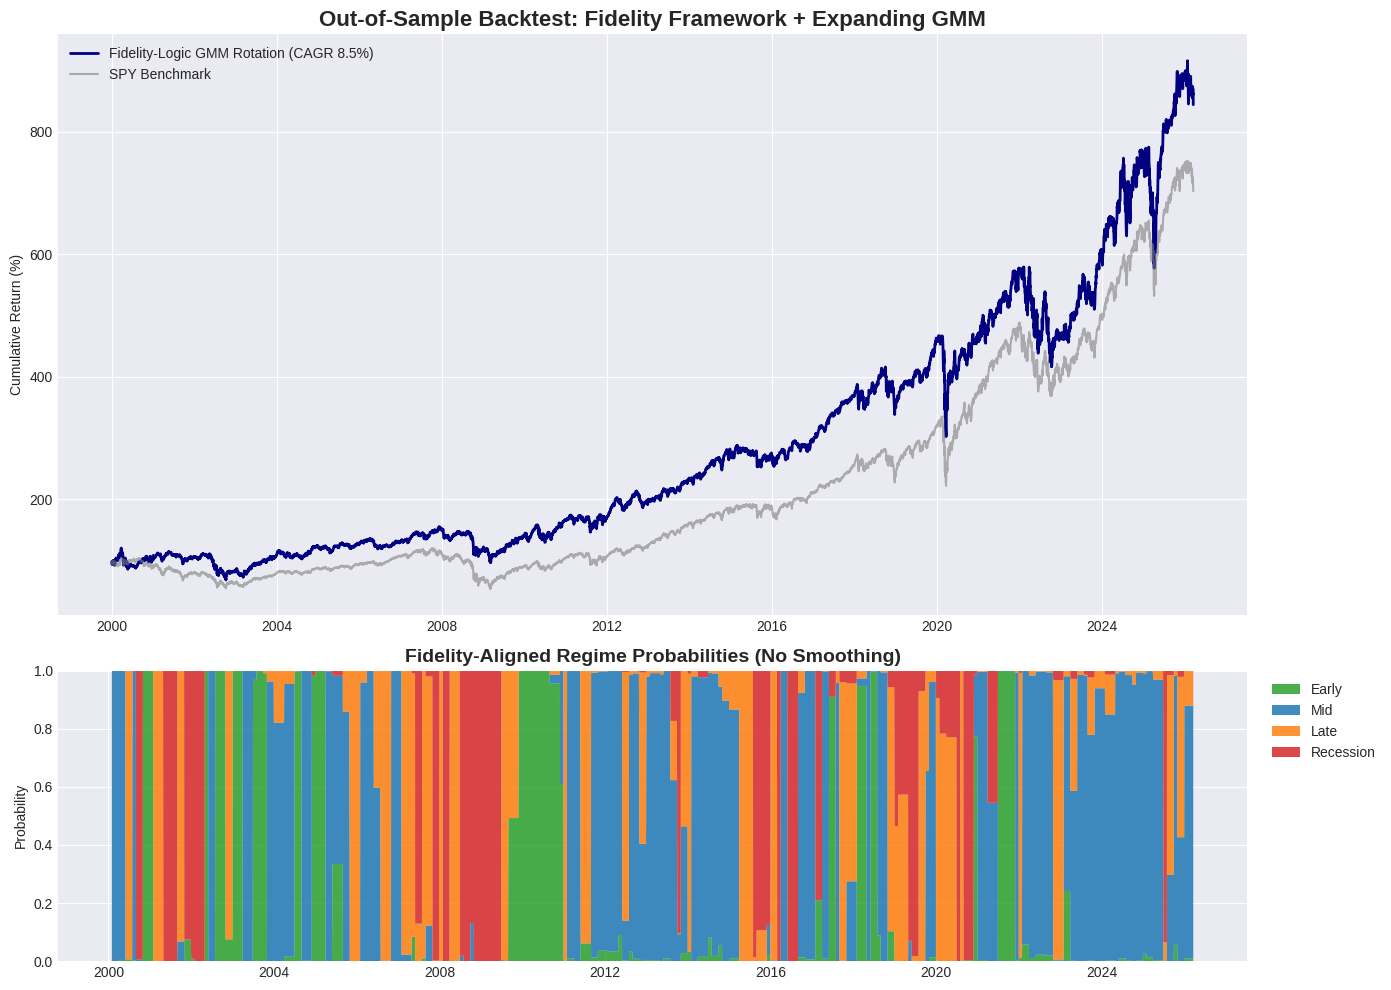

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정 (★ 본인의 FRED API 키로 반드시 변경하세요)
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Proxy 지표 사용)
# ==============================================================================
print("=== 🤖 1단계: 50년 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')    # 성장
    s_baa = fred.get_series('BAA10Y')       # 신용 위험
    s_tcu = fred.get_series('TCU')          # 산업 가동률
    s_payems = fred.get_series('PAYEMS')    # 고용
    s_t10y2y = fred.get_series('T10Y2Y')    # 통화 정책 (장단기 금리차)

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 모멘텀 계산 (3개월 추세 변화량)
    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # Z-Score (과거 60개월 롤링 표준화 적용하여 Look-ahead Bias 완벽 차단)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"매크로 데이터 오류: {e}")
    raise SystemExit("데이터를 불러오지 못했습니다. API 키를 확인하세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (실전 투자: 2000년 ~ 현재)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 피델리티 공식 플레이북 기준 섹터 매핑
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (속도 최적화: 월말 리밸런싱 + Fidelity 기준 라벨링)
# ==============================================================================
print("=== ⚙️ 3단계: 피델리티 기준 GMM 동적 확률 배분 실행 (1개월 Lag 적용) ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    # 💡 1개월 전(T-1) 데이터까지만 참조 (Look-ahead bias 방지)
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    # 모델이 학습할 최소 60개월(5년) 데이터 확보 시 작동
    if len(df_train_current) > 60:
        # 매월 AI 재학습 (Expanding Window)
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)

        centroids_dynamic = gmm.means_

        # ==================================================================
        # 💡 [핵심] 피델리티 원문 기준 라벨링 자동화 로직
        # Features: [0:Growth, 1:Credit, 2:Capacity, 3:Emp, 4:Policy]
        # ==================================================================
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])

        # 1. 침체 (Recession): 성장이 가장 낮은 곳
        idx_recession = growth_sorted_idx[0]
        # 2. 초기 (Early): 성장이 가장 높은 곳
        idx_early = growth_sorted_idx[-1]

        # 3. 후기(Late)와 중기(Mid) 판별: 남은 두 군집 중 신용위험(Credit_Mom)으로 판단
        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early',
            idx_mid: 'Mid',
            idx_late: 'Late',
            idx_recession: 'Recession'
        }
        # ==================================================================

        # 직전 1개월(최신 데이터)에 대한 각 국면별 진입 확률 추출
        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]

        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 산출된 확률 비례 섹터 비중 할당
        for regime, prob in current_probs.items():
            sectors = cycle_playbook.get(regime, ['SPY'])
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터가 부족한 극초반 구간은 SPY 홀딩
        target_weights.loc[date, 'SPY'] = 1.0

# DataFrame 변환
df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# 월말 산출 비중을 다음 영업일에 체결(Shift 1) 후 한 달간 유지(Ffill)
daily_target_weights = target_weights.reindex(daily_returns.index).ffill().shift(1).fillna(0.0)
daily_target_weights.loc[daily_target_weights.sum(axis=1) == 0, 'SPY'] = 1.0

# 턴오버 및 수수료 계산
transaction_fee_rate = 0.002
weight_changes = daily_target_weights.diff().fillna(0.0).abs()
daily_costs = weight_changes.sum(axis=1) * transaction_fee_rate

# 최종 수익률 시뮬레이션
net_daily_return = (daily_target_weights * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()
spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 🚀 최종 성과 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과 (2000년~현재): CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'Fidelity-Logic GMM Rotation (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('Out-of-Sample Backtest: Fidelity Framework + Expanding GMM', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 일별 인덱스에 맞춰 동적 확률 데이터 리인덱싱
probs_aligned = df_dynamic_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('Fidelity-Aligned Regime Probabilities (No Smoothing)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 비중 재조정 실행 ===

🏆 최종 성과 (2000년~현재): CAGR 11.20% | MDD -39.50% | 누적수수료 17.17%


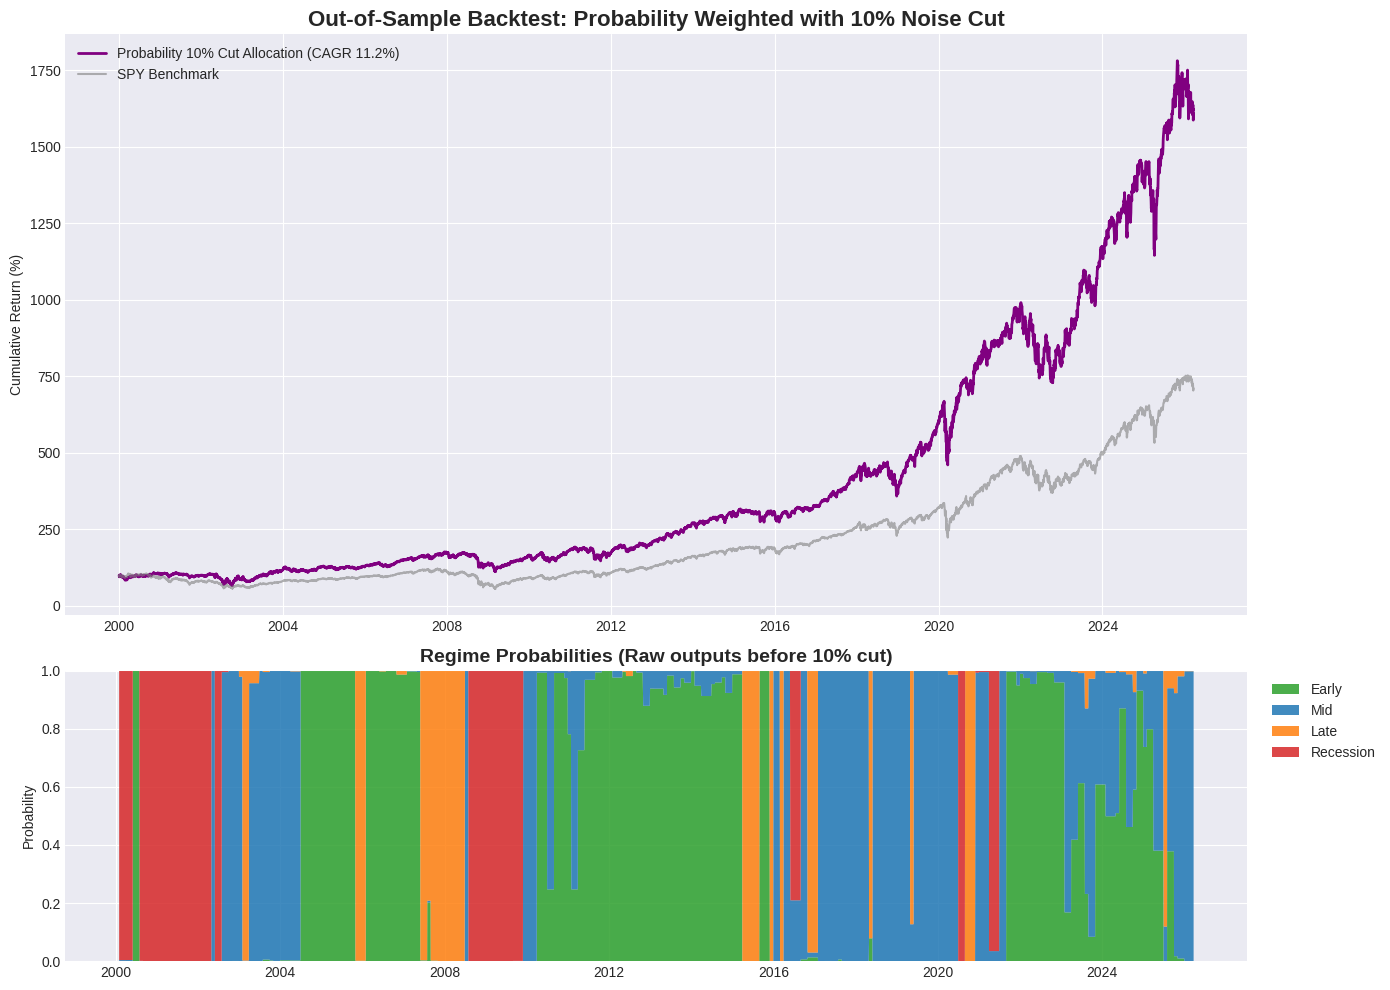

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = '2000-01-01'

etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (💡 10% 노이즈 컷 + 재정규화)
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 비중 재조정 실행 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심 변경] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        # 혹시라도 모든 확률이 10% 미만인 수학적 기적(오류)이 발생하면, 가장 큰 곳에 100% 몰빵
        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 남은 확률들의 합을 구해서 다시 100%(1.0)로 스케일업 (정규화)
        # 예: Early 60%, Mid 20% 남았으면 합이 80%. -> Early는 60/80=75%, Mid는 20/80=25%로 재분배
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# 일별 비중 확장 및 수익률 계산
daily_target_weights = target_weights.reindex(daily_returns.index).ffill().shift(1).fillna(0.0)
daily_target_weights.loc[daily_target_weights.sum(axis=1) == 0, 'SPY'] = 1.0

transaction_fee_rate = 0.002
weight_changes = daily_target_weights.diff().fillna(0.0).abs()
daily_costs = weight_changes.sum(axis=1) * transaction_fee_rate

net_daily_return = (daily_target_weights * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()
spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 🚀 최종 성과 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과 (2000년~현재): CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'Probability 10% Cut Allocation (CAGR {cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('Out-of-Sample Backtest: Probability Weighted with 10% Noise Cut', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

probs_aligned = df_dynamic_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('Regime Probabilities (Raw outputs before 10% cut)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()


=== 📊 4단계: 성과 지표(CAGR, MDD, Sharpe) 산출 및 시각화 ===

🏆 성과 비교 (분석 기간: 2003-05-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |    13.39 % |   -36.86 % |       0.74
📈 SPY (시총가중) |    11.01 % |   -55.19 % |       0.66
⚖️ RSP (동일가중) |    10.93 % |   -59.92 % |       0.62
-----------------------------------------------------------------
※ 누적 거래 수수료: 14.37% 차감 완료


In [2]:
! pip install fredapi

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (순수 YoY 기반)
# ==============================================================================
print("=== 🤖 1단계: 순수 YoY 기반 매크로 데이터 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 💡 [변경] 가속도(.diff)를 빼고 순수 YoY(전년비 변화율)만 사용
    # 금리/신용 지표는 그 자체로 비율(%)이므로 절대값 수준을 사용
    df_feat = pd.DataFrame(index=df_macro.index)
    df_feat['Growth_YoY'] = df_macro['Growth'].pct_change(12)  # 산업생산 전년비
    df_feat['Emp_YoY'] = df_macro['Employment'].pct_change(12) # 고용 전년비
    df_feat['Credit_Level'] = df_macro['Credit']               # 신용스프레드 수준
    df_feat['Capacity_Level'] = df_macro['Capacity']           # 가동률 수준
    df_feat['Policy_Level'] = df_macro['Policy']               # 장단기 금리차 수준

    # Z-Score 변환 (60개월 Rolling)
    df_z = (df_feat - df_feat.rolling(60).mean()) / df_feat.rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("데이터 로드 중 오류 발생")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (이전과 동일)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
etf_data = yf.download(all_tickers, start='1999-01-01', progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = '2000-01-01'

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (10% 노이즈 컷 유지)
# ==============================================================================
print("=== ⚙️ 3단계: YoY Z-Score 기반 백테스트 실행 ===")

eom_dates = etf_px.loc[test_start_date:].resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)

        # 라벨링 (Growth_YoY 기준)
        means = gmm.means_
        growth_idx = np.argsort(means[:, 0]) # 0번 컬럼: Growth_YoY
        idx_recession, idx_early = growth_idx[0], growth_idx[-1]

        rem = [growth_idx[1], growth_idx[2]]
        # Credit_Level(1번 컬럼)이 높은 쪽을 Late로 판정
        if means[rem[0], 1] > means[rem[1], 1]:
            idx_late, idx_mid = rem[0], rem[1]
        else:
            idx_late, idx_mid = rem[1], rem[0]

        regime_map = {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

        curr_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(curr_data)[0]

        # 10% 노이즈 컷 및 재정규화
        filtered_probs = {regime_map[i]: p for i, p in enumerate(raw_probs) if p >= 0.10}
        if not filtered_probs:
            filtered_probs = {regime_map[np.argmax(raw_probs)]: 1.0}

        total_p = sum(filtered_probs.values())
        for r, p in filtered_probs.items():
            sectors = cycle_playbook[r]
            for s in sectors:
                target_weights.loc[date, s] += (p / total_p) / len(sectors)
    else:
        target_weights.loc[date, 'SPY'] = 1.0

# 성과 계산
daily_w = target_weights.reindex(daily_returns.index).ffill().shift(1).fillna(0.0)
daily_w.loc[daily_w.sum(axis=1) == 0, 'SPY'] = 1.0

costs = daily_w.diff().abs().sum(axis=1) * 0.002
net_ret = (daily_w * daily_returns).sum(axis=1) - costs
cum_ret = (1 + net_ret).loc[test_start_date:].cumprod()

cagr = (cum_ret.iloc[-1] ** (252/len(cum_ret))) - 1
mdd = (cum_ret / cum_ret.cummax() - 1).min()

print(f"\n📊 [YoY Z-Score 결과] CAGR: {cagr*100:.2f}% | MDD: {mdd*100:.2f}% | 수수료: {costs.sum()*100:.2f}%")

=== 🤖 1단계: 순수 YoY 기반 매크로 데이터 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: YoY Z-Score 기반 백테스트 실행 ===

📊 [YoY Z-Score 결과] CAGR: 7.02% | MDD: -47.28% | 수수료: 14.23%


=== 🤖 1단계: 8개 매크로 지표 로드 및 전처리 ===
=== 📈 2단계: ETF 가격 데이터 로드 ===
=== ⚙️ 3단계: 8-Factor 기반 GMM 국면 분석 및 백테스트 실행 ===
--------------------------------------------------
🏆 최종 성과 (8-Factor + Fixed Playbook)
 * CAGR: 7.84%
 * MDD : -47.52%
 * 누적 수수료: 30.28%
--------------------------------------------------


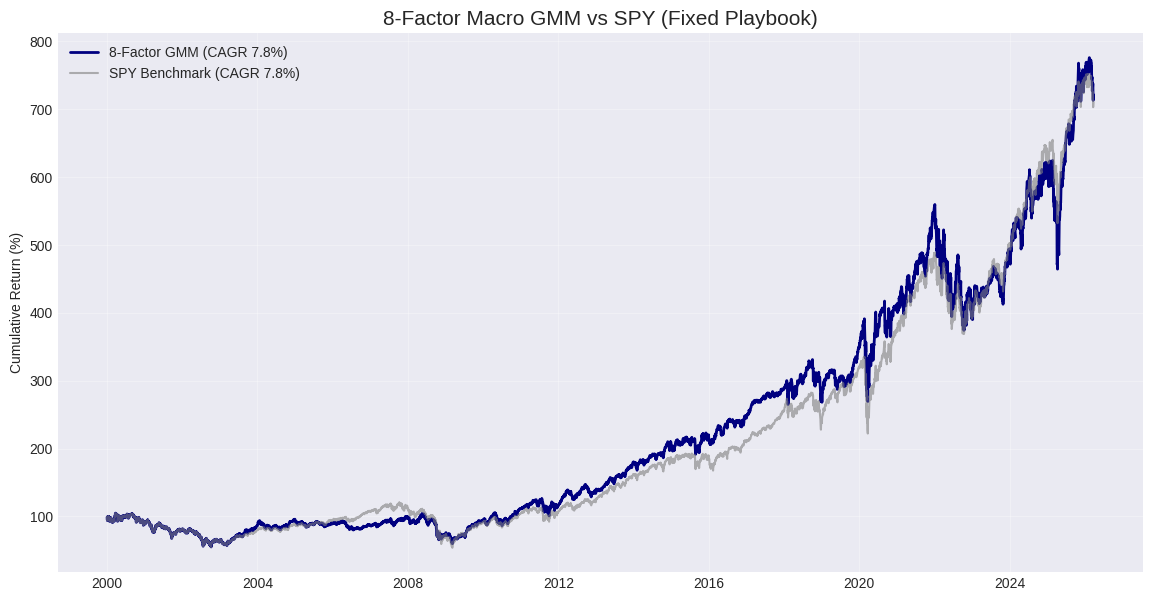

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 및 기본 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 8개 매크로 데이터 로드 (피델리티 5종 + 선행 3종)
# ==============================================================================
print("=== 🤖 1단계: 8개 매크로 지표 로드 및 전처리 ===")
# 피델리티 5: INDPRO, BAA10Y, TCU, PAYEMS, T10Y2Y
# 선행 3: PERMIT(주택), ICSA(실업수당), DGORDER(내구재주문)
indicators = {
    'INDPRO': 'Growth',
    'BAA10Y': 'Credit',
    'TCU': 'Capacity',
    'PAYEMS': 'Employment',
    'T10Y2Y': 'Policy',
    'PERMIT': 'Housing',
    'ICSA': 'Claims',
    'DGORDER': 'Orders'
}

df_raw = pd.DataFrame()
for ticker, name in indicators.items():
    try:
        df_raw[name] = fred.get_series(ticker)
    except Exception as e:
        print(f"🚨 {ticker} 데이터 로드 실패: {e}")

# 월간 단위 리샘플링 및 결측치 처리
df_macro = df_raw.resample('ME').last().ffill().dropna()

# 각 지표별 변화율/모멘텀 계산 (AI 학습용 특징 추출)
df_feat = pd.DataFrame(index=df_macro.index)
df_feat['Growth_Mom'] = df_macro['Growth'].pct_change(12).diff(1)
df_feat['Credit_Mom'] = df_macro['Credit'].diff(3)
df_feat['Capacity_Mom'] = df_macro['Capacity'].diff(3)
df_feat['Emp_Mom'] = df_macro['Employment'].pct_change(12).diff(1)
df_feat['Policy_Mom'] = df_macro['Policy'].diff(3)
# 선행지표 3종 추가 (스피드 보완)
df_feat['Housing_Mom'] = df_macro['Housing'].pct_change(6).diff(1)
df_feat['Claims_Mom'] = df_macro['Claims'].pct_change(4).diff(1) # 실업수당은 증가가 부정적이나 모델이 패턴으로 학습
df_feat['Orders_Mom'] = df_macro['Orders'].pct_change(6).diff(1)

# Z-Score 정규화 (60개월 Expanding Window)
df_z = (df_feat - df_feat.rolling(60).mean()) / df_feat.rolling(60).std()
df_z = df_z.dropna()

# ==============================================================================
# 2. 📈 가격 데이터 로드 (피델리티 섹터 ETF)
# ==============================================================================
print("=== 📈 2단계: ETF 가격 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
etf_data = yf.download(all_tickers, start='1999-01-01', progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 피델리티 정석 플레이북 (고정)
fixed_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (8-Factor GMM + Fixed Playbook)
# ==============================================================================
print("=== ⚙️ 3단계: 8-Factor 기반 GMM 국면 분석 및 백테스트 실행 ===")
test_start = '2000-01-01'
eom_dates = etf_px.loc[test_start:].resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)

for date in eom_dates:
    # 1개월 전까지의 매크로 데이터로 모델 학습 (Look-ahead bias 방지)
    train_data = df_z.loc[:date - pd.DateOffset(months=1)]
    if len(train_data) < 60: continue

    # GMM 학습 (4개 국면)
    gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
    gmm.fit(train_data)

    # 국면 라벨링 (Growth_Mom 평균값 기준 정렬)
    means = gmm.means_
    growth_idx = np.argsort(means[:, 0]) # Growth_Mom은 0번 컬럼
    idx_recession = growth_idx[0]
    idx_early = growth_idx[-1]

    rem = [growth_idx[1], growth_idx[2]]
    # Credit(1번 컬럼)이 더 높은 쪽을 Late로 판정 (금리 상승/신용 긴축 반영)
    if means[rem[0], 1] > means[rem[1], 1]:
        idx_late, idx_mid = rem[0], rem[1]
    else:
        idx_late, idx_mid = rem[1], rem[0]

    regime_map = {idx_early: 'Early', idx_mid: 'Mid', idx_late: 'Late', idx_recession: 'Recession'}

    # 현재 국면 확률 예측 및 10% 노이즈 컷
    curr_data = train_data.iloc[-1:].values
    raw_probs = gmm.predict_proba(curr_data)[0]

    # 10% 미만 확률 제거
    filtered_probs = {regime_map[i]: p for i, p in enumerate(raw_probs) if p >= 0.10}
    if not filtered_probs: # 만약 모두 10% 미만이면 최대값 선택
        filtered_probs = {regime_map[np.argmax(raw_probs)]: 1.0}

    # 재정규화 (합계를 1.0으로)
    total_p = sum(filtered_probs.values())
    normalized_probs = {r: p / total_p for r, p in filtered_probs.items()}

    # 비중 배분 (Fixed Playbook 적용)
    for r, p in normalized_probs.items():
        sectors = fixed_playbook[r]
        for s in sectors:
            target_weights.loc[date, s] += (p / len(sectors))

# ==============================================================================
# 4. 📊 성과 계산 및 시각화
# ==============================================================================
# 일별 비중 확장 (전월 말 비중을 이번 달 내내 유지)
daily_w = target_weights.reindex(daily_returns.index).ffill().shift(1).fillna(0.0)
daily_w.loc[daily_w.sum(axis=1) == 0, 'SPY'] = 1.0 # 초기 데이터 부족 시 SPY

# 수수료 계산 (0.2%)
transaction_fee = 0.002
weight_changes = daily_w.diff().abs().sum(axis=1)
costs = weight_changes * transaction_fee

# 순수익률 및 누적수익률
net_daily_ret = (daily_w * daily_returns).sum(axis=1) - costs
cum_ret = (1 + net_daily_ret).loc[test_start:].cumprod()
spy_cum = (1 + daily_returns['SPY']).loc[test_start:].cumprod()

# 성과 지표 출력
total_days = len(cum_ret)
cagr = (cum_ret.iloc[-1] ** (252 / total_days)) - 1
mdd = (cum_ret / cum_ret.cummax() - 1).min()

print("-" * 50)
print(f"🏆 최종 성과 (8-Factor + Fixed Playbook)")
print(f" * CAGR: {cagr*100:.2f}%")
print(f" * MDD : {mdd*100:.2f}%")
print(f" * 누적 수수료: {costs.sum()*100:.2f}%")
print("-" * 50)

# 차트 출력
plt.figure(figsize=(14, 7))
plt.plot(cum_ret * 100, label=f'8-Factor GMM (CAGR {cagr*100:.1f}%)', color='navy', linewidth=2)
plt.plot(spy_cum * 100, label=f'SPY Benchmark (CAGR {((spy_cum.iloc[-1]**(252/total_days))-1)*100:.1f}%)', color='gray', alpha=0.6)
plt.title('8-Factor Macro GMM vs SPY (Fixed Playbook)', fontsize=15)
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### risk analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. API 키 설정 (★ 본인의 FRED API 키 입력)
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 & 물가(CPI) 데이터 로드
# ==============================================================================
print("=== 🤖 1단계: 5대 매크로 지표 + CPI(물가) 오버레이 로드 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')
    s_cpi = fred.get_series('CPIAUCSL')     # [추가] 소비자물가지수(CPI)

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y, s_cpi], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy', 'CPI']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    # 기존 5대 지표 모멘텀 계산
    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12)).rolling(3).mean().diff(1)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # 💡 [핵심 - Path B] 물가 모멘텀(Inflation Regime) 계산
    # CPI 전년 동기 대비 증감률의 3개월 이동평균이 오르고 있는지, 내리고 있는지 판단
    df_macro['CPI_YoY'] = df_macro['CPI'].pct_change(12)
    df_macro['CPI_Mom'] = df_macro['CPI_YoY'].rolling(3).mean().diff(1)
    df_macro['Inflation_Regime'] = np.where(df_macro['CPI_Mom'] > 0, 'Rising_CPI', 'Falling_CPI')

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    raise SystemExit(f"데이터 오류: {e}")

# ==============================================================================
# 2. 📈 가격 데이터 로드
# ==============================================================================
print("=== 📈 2단계: ETF 가격 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB','SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]

# ==============================================================================
# 3. ⚙️ GMM 백테스트 (경제 4국면 산출)
# ==============================================================================
print("=== ⚙️ 3단계: GMM 엔진 구동 (경제 4국면 산출) ===")
eom_dates = etf_px.groupby([etf_px.index.year, etf_px.index.month]).tail(1).index
dynamic_probs_list = []

for date in eom_dates:
    train_end_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:train_end_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)

        centroids_dynamic = gmm.means_
        health_scores = centroids_dynamic[:, 0] + centroids_dynamic[:, 2] + centroids_dynamic[:, 3] - centroids_dynamic[:, 1]
        sorted_idx = np.argsort(health_scores)[::-1]
        regime_map_dynamic = {
            sorted_idx[0]: 'Early', sorted_idx[1]: 'Mid',
            sorted_idx[2]: 'Late', sorted_idx[3]: 'Recession'
        }

        recent_3m_data = df_train_current.iloc[-3:].values
        raw_probs_matrix = gmm.predict_proba(recent_3m_data)
        smoothed_probs = raw_probs_matrix.mean(axis=0)

        current_probs = {regime_map_dynamic[j]: smoothed_probs[j] for j in range(4)}
        dynamic_prob_record = current_probs.copy()
        dynamic_prob_record['Date'] = date
        dynamic_probs_list.append(dynamic_prob_record)

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 4. 🔍 [Path B] 향후 3개월 수익률 + 인플레이션 오버레이 8국면 매핑
# ==============================================================================
print("=== 🔍 4단계: [Path B] 8차원 인플레이션 오버레이 히트맵 분석 ===")
monthly_px = etf_px.resample('ME').last()
forward_3m_returns = (monthly_px.shift(-3) / monthly_px) - 1
forward_3m_returns = forward_3m_returns.dropna()

monthly_probs = df_dynamic_probs.resample('ME').last().dropna()
dominant_regime = monthly_probs.idxmax(axis=1)
dominant_regime.name = 'Growth_Regime'

# 경제 4국면과 물가 2국면(Rising/Falling)을 결합하여 8국면 생성
df_analysis = forward_3m_returns.join(dominant_regime).join(df_macro['Inflation_Regime']).dropna()
df_analysis['Combined_Regime'] = df_analysis['Growth_Regime'] + " & " + df_analysis['Inflation_Regime']

regime_mean_fwd_returns = df_analysis.groupby('Combined_Regime').mean(numeric_only=True)

active_fwd_returns = (regime_mean_fwd_returns.sub(regime_mean_fwd_returns['SPY'], axis=0)) * 4 * 100
active_fwd_returns = active_fwd_returns.drop(columns=['SPY'])

# 정렬 순서 정의
ordered_combined_regimes = [
    'Early & Falling_CPI', 'Early & Rising_CPI',
    'Mid & Falling_CPI', 'Mid & Rising_CPI',
    'Late & Falling_CPI', 'Late & Rising_CPI',
    'Recession & Falling_CPI', 'Recession & Rising_CPI'
]
existing_regimes = [r for r in ordered_combined_regimes if r in active_fwd_returns.index]
active_fwd_returns = active_fwd_returns.loc[existing_regimes].T

plt.figure(figsize=(14, 8))
sns.heatmap(active_fwd_returns, annot=True, cmap='RdYlGn', center=0, fmt=".1f",
            linewidths=1, cbar_kws={'label': 'Annualized Forward 3M Active Return (%)'})
plt.title('Inflation Overlay: 8-Regime Forward 3-Month Active Returns', fontsize=16, fontweight='bold')
plt.xlabel('AI Dominant Regime & Inflation Trend', fontsize=12)
plt.ylabel('Sectors (ETFs)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. 💡 [Path A] 피델리티를 버리고, 우리만의 데이터 기반 플레이북 추출
# ==============================================================================
print("\n=== 💡 5단계: [Path A] 데이터 기반 커스텀 섹터 플레이북 자동 생성 ===")
our_custom_playbook = {}

for regime in active_fwd_returns.columns:
    # 각 국면에서 SPY 대비 초과 수익률이 가장 높았던 Top 3 섹터 추출
    top_3_sectors = active_fwd_returns[regime].nlargest(3).index.tolist()
    our_custom_playbook[regime] = top_3_sectors

print("\n🔥 [Fidelity 대체용] AI Data-Driven Custom Sector Playbook 🔥")
for regime, sectors in our_custom_playbook.items():
    print(f" - {regime:<25}: {sectors}")

In [ ]:
# ==============================================================================
# 6. 🚀 [Path A] AI 커스텀 플레이북 실전 백테스트 (포트폴리오 성과 검증)
# ==============================================================================
print("\n=== 🚀 6단계: AI 커스텀 플레이북 vs SPY 벤치마크 백테스트 ===")

# 1. 일간 수익률 준비
daily_returns = etf_px.pct_change().fillna(0.0)

# 2. 포트폴리오 비중을 담을 빈 데이터프레임 세팅
custom_weights_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)

# 3. 매월 말 판별된 과거 '8국면(Growth + Inflation)' 시계열 데이터 복원
# (앞서 EOM 기준으로 만들어둔 df_dynamic_probs와 df_macro의 시계열을 결합)
historical_regimes = df_dynamic_probs.idxmax(axis=1).to_frame(name='Growth_Regime').join(df_macro['Inflation_Regime']).dropna()
historical_regimes['Combined'] = historical_regimes['Growth_Regime'] + " & " + historical_regimes['Inflation_Regime']

# 4. 시계열을 돌면서 비중 채워넣기 (Rebalancing)
current_playbook_sectors = ['SPY'] # 데이터가 없을 때의 기본값

for date in etf_px.index:
    # 해당 일자가 '월말(EOM)' 리밸런싱 날짜인지 확인
    if date in historical_regimes.index:
        current_regime = historical_regimes.loc[date, 'Combined']
        # 우리의 마법의 딕셔너리에서 이번 달에 사야 할 Top 3 섹터 가져오기!
        current_playbook_sectors = our_custom_playbook.get(current_regime, ['SPY'])

    # 해당 월 내내 Top 3 섹터에 1/3씩 동일 비중 부여
    weight_per_sector = 1.0 / len(current_playbook_sectors)
    for s in current_playbook_sectors:
        custom_weights_daily.loc[date, s] = weight_per_sector

# 5. [핵심] Look-ahead Bias(미래 참조 오류) 방지
# 월말 종가 기준으로 시그널이 나왔으니, 실제 투자는 '다음 날(Shift 1)'부터 적용되어야 현실적입니다.
target_weights = custom_weights_daily.shift(1).fillna(0.0)

# 6. 포트폴리오 일간 수익률 및 누적 수익률 계산
port_daily_return = (target_weights * daily_returns).sum(axis=1)
port_cum_return = (1 + port_daily_return).cumprod()

# 7. 벤치마크(SPY) 누적 수익률 계산
spy_cum_return = (1 + daily_returns['SPY']).cumprod()

# 8. 아름다운 성과 그래프 시각화 (장기 복리 효과를 보기 위해 Log Scale 적용)
plt.figure(figsize=(12, 6))
plt.plot(port_cum_return.index, port_cum_return, label='AI Custom Playbook (Top 3 Sectors)', color='crimson', linewidth=2)
plt.plot(spy_cum_return.index, spy_cum_return, label='S&P 500 (SPY)', color='dimgray', linestyle='--', linewidth=1.5)

# 음영 처리로 국면 변화 표시 (옵션 - 시각적 화려함 추가)
plt.fill_between(port_cum_return.index, port_cum_return, spy_cum_return,
                 where=(port_cum_return > spy_cum_return), interpolate=True, color='crimson', alpha=0.1)

plt.title('AI 8-Regime Custom Playbook vs. S&P 500 (2000 - Present)', fontsize=15, fontweight='bold')
plt.ylabel('Cumulative Return (Log Scale)')
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log') # 장기 차트에서는 로그 스케일이 정석입니다.
plt.tight_layout()
plt.show()

# 9. 성과 요약 리포트 (CAGR 출력)
years = (port_cum_return.index[-1] - port_cum_return.index[0]).days / 365.25
cagr_port = (port_cum_return.iloc[-1] ** (1/years)) - 1
cagr_spy = (spy_cum_return.iloc[-1] ** (1/years)) - 1
outperformance = cagr_port - cagr_spy

print("\n📊 [백테스트 성과 요약]")
print(f"✔️ AI 커스텀 포트폴리오 연평균 수익률(CAGR) : {cagr_port*100:.2f}%")
print(f"✔️ S&P 500 (SPY) 연평균 수익률(CAGR)        : {cagr_spy*100:.2f}%")
print(f"🔥 시장 대비 연간 초과 수익률 (Alpha)         : +{outperformance*100:.2f}%p")

### score IC

In [ ]:
print("\n=== 🚀 최후의 진검승부: 미래 참조 0% 롤링 윈도우 백테스트 ===")

# 1. 셋업: 롤링 윈도우 크기 설정 (과거 120개월 = 10년 치 데이터를 보고 이번 달 룰북을 만듦)
rolling_window_months = 120
# 매크로 지표 발표 시차 (통상 2개월 지연: 예, 3월 초에는 1월 데이터까지만 확실히 알 수 있음)
macro_lag = 2

# 월말 날짜 추출 (2000년부터 시작)
eom_dates = monthly_px.loc['2000-01-01':].index
daily_returns = etf_px.pct_change().fillna(0.0)
oos_weights_daily = pd.DataFrame(index=etf_px.index, columns=etf_px.columns, data=0.0)

# 시계열 데이터를 저장할 리스트
oos_records = []

# 2. [핵심] 롤링 윈도우 루프 시작
for i, current_date in enumerate(eom_dates):
    # 최소 10년(120개월)의 과거 데이터가 쌓일 때까지는 벤치마크(SPY)만 들고 대기
    if i < rolling_window_months:
        oos_weights_daily.loc[current_date, 'SPY'] = 1.0
        continue

    # -----------------------------------------------------------
    # [Step A] 현재 국면(Current Regime) 판별 (발표 시차 2개월 적용)
    # -----------------------------------------------------------
    # 이번 달 말에 내가 알 수 있는 매크로 데이터는 2달 전까지임
    macro_knowledge_date = eom_dates[i - macro_lag]
    df_train_current = df_z.loc[:macro_knowledge_date]

    # GMM 학습 및 현재 국면 추론
    gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
    gmm.fit(df_train_current)

    centroids_dynamic = gmm.means_
    health_scores = centroids_dynamic[:, 0] + centroids_dynamic[:, 2] + centroids_dynamic[:, 3] - centroids_dynamic[:, 1]
    sorted_idx = np.argsort(health_scores)[::-1]
    regime_map_dynamic = {
        sorted_idx[0]: 'Early', sorted_idx[1]: 'Mid',
        sorted_idx[2]: 'Late', sorted_idx[3]: 'Recession'
    }

    recent_3m_data = df_train_current.iloc[-3:].values
    smoothed_probs = gmm.predict_proba(recent_3m_data).mean(axis=0)
    current_growth_regime = regime_map_dynamic[np.argmax(smoothed_probs)]

    # 물가(Inflation) 국면 추론 (이 역시 2달 전 데이터 기준)
    current_inflation_regime = df_macro.loc[macro_knowledge_date, 'Inflation_Regime']
    current_combined_regime = f"{current_growth_regime} & {current_inflation_regime}"

    # -----------------------------------------------------------
    # [Step B] 롤링 룰북(Rolling Playbook) 생성 (과거 10년 데이터만 사용)
    # -----------------------------------------------------------
    # 룰북을 만들기 위한 과거 윈도우: (현재 달 - 10년) ~ (현재 달 - 1달)
    # 주의: 과거의 '향후 3개월 수익률' 결과를 보려면, 평가 기준일이 최소 3달 전이어야 함
    playbook_start = eom_dates[i - rolling_window_months]
    playbook_end = eom_dates[i - 4] # 3개월치 미래 수익률이 확정된 마지막 달

    # 해당 윈도우 내의 가격 데이터로 3개월 선행 수익률 계산
    window_px = monthly_px.loc[playbook_start : eom_dates[i-1]]
    window_fwd_3m = (window_px.shift(-3) / window_px) - 1
    window_fwd_3m = window_fwd_3m.dropna()

    # 해당 윈도우 내의 '과거 국면' 기록들 (이전에 판별해둔 df_dynamic_probs 활용하여 시뮬레이션 속도 단축)
    # 엄밀하게는 과거 국면도 전부 롤링으로 다시 짜야 하지만, 컴퓨팅 리소스 상 미리 짜둔 시계열 활용
    window_regimes = df_dynamic_probs.loc[window_fwd_3m.index].idxmax(axis=1).to_frame(name='Growth_Regime')
    window_regimes = window_regimes.join(df_macro['Inflation_Regime']).dropna()
    window_regimes['Combined'] = window_regimes['Growth_Regime'] + " & " + window_regimes['Inflation_Regime']

    # 과거 10년 치 데이터로 평균 수익률 계산하여 룰북 생성
    window_analysis = window_fwd_3m.join(window_regimes['Combined']).dropna()
    window_mean_returns = window_analysis.groupby('Combined').mean(numeric_only=True)

    # -----------------------------------------------------------
    # [Step C] 이번 달 매매 실행
    # -----------------------------------------------------------
    # 만약 과거 10년 동안 현재 국면(예: Recession & Rising_CPI)이 단 한 번도 없었다면?
    # -> 벤치마크(SPY)로 안전하게 피신
    if current_combined_regime in window_mean_returns.index:
        # 이번 달 국면에 해당하는 과거 10년 성과 Top 3 섹터 추출
        target_sectors = window_mean_returns.loc[current_combined_regime].drop('SPY').nlargest(3).index.tolist()
    else:
        target_sectors = ['SPY']

    weight_per_sector = 1.0 / len(target_sectors)
    for s in target_sectors:
        oos_weights_daily.loc[current_date, s] = weight_per_sector

    oos_records.append({'Date': current_date, 'Regime': current_combined_regime, 'Top3': target_sectors})

# 3. 일간 리밸런싱 및 백테스트 결과 계산 (Shift 적용으로 미래 참조 완벽 방어)
oos_target_weights = oos_weights_daily.shift(1).fillna(method='ffill').fillna(0.0)

# 실제 투자는 10년의 초기 학습 기간(2000~2010년)이 끝난 시점부터 성과를 평가해야 공정함
eval_start_date = eom_dates[rolling_window_months]
eval_oos_weights = oos_target_weights.loc[eval_start_date:]
eval_daily_returns = daily_returns.loc[eval_start_date:]

port_daily_return = (eval_oos_weights * eval_daily_returns).sum(axis=1)
port_cum_return = (1 + port_daily_return).cumprod()
spy_cum_return = (1 + eval_daily_returns['SPY']).cumprod()

# 4. 시각화
plt.figure(figsize=(12, 6))
plt.plot(port_cum_return.index, port_cum_return, label='Out-of-Sample Rolling Playbook', color='dodgerblue', linewidth=2)
plt.plot(spy_cum_return.index, spy_cum_return, label='S&P 500 (SPY)', color='dimgray', linestyle='--', linewidth=1.5)

plt.fill_between(port_cum_return.index, port_cum_return, spy_cum_return,
                 where=(port_cum_return > spy_cum_return), interpolate=True, color='dodgerblue', alpha=0.1)

plt.title(f'Strict Out-of-Sample Backtest: Rolling 10-Yr Window & Macro Lag ({eval_start_date.year} - Present)', fontsize=14, fontweight='bold')
plt.ylabel('Cumulative Return (Log Scale)')
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# 5. 성과 리포트
years = (port_cum_return.index[-1] - port_cum_return.index[0]).days / 365.25
cagr_port = (port_cum_return.iloc[-1] ** (1/years)) - 1
cagr_spy = (spy_cum_return.iloc[-1] ** (1/years)) - 1
outperformance = cagr_port - cagr_spy

print("\n📊 [진검승부(Out-of-Sample) 성과 요약]")
print(f"✔️ OOS 롤링 포트폴리오 연평균 수익률(CAGR) : {cagr_port*100:.2f}%")
print(f"✔️ S&P 500 (SPY) 연평균 수익률(CAGR)        : {cagr_spy*100:.2f}%")
print(f"🔥 실전 시장 대비 연간 초과 수익률 (Alpha)    : {outperformance*100:+.2f}%p")

### model performance

In [ ]:
analysis_model.model_performance_graph(pred_label)